In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torchvision.models as models
import torchxrayvision as xrv
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset

# Datasets Inference Heatmap

In [6]:
# 1. Load the data
# We assume the file is named 'inference.csv' and uses ';' as delimiter
df = pd.read_csv('inference.csv', delimiter=';')
df['Dataset'] = df['Dataset'].replace({'Enlarged Cardiomediastinum': 'Enlarged Cardio.'})
df = df.rename(columns={'Object': 'Object-CXR'})
df = df.sort_values(by='Merged', ascending=False)
df


,Dataset,CheXpert,MIMIC,PadChest,NIH,OpenI,VinDr,SIIM-ACR,RSNA,Object-CXR,Kermany,Merged
4,Enlarged Cardio.,"91,04","70,49","87,34",NaN,"87,11",NaN,NaN,NaN,NaN,NaN,"95,30"
3,Edema,"88,75","88,46","93,26","89,08","86,36",NaN,NaN,NaN,NaN,NaN,"94,00"
2,Consolidation,"89,07","80,30","85,37","81,01","77,12","93,91",NaN,NaN,NaN,NaN,"93,97"
11,Support Device,"91,60","89,28","97,54",NaN,"74,06",NaN,NaN,NaN,"75,94",NaN,"93,95"
8,Pleural Effusion,"89,13","90,30","95,59","88,97","92,01","96,65",NaN,NaN,NaN,NaN,"92,62"
1,Cardiomegaly,"89,22","80,84","91,19","90,28","91,42","97,54",NaN,NaN,NaN,NaN,"91,75"
0,Atelectasis,"90,01","80,63","81,12","80,23","85,10","84,95",NaN,NaN,NaN,NaN,"89,63"
10,Pneumothorax,"86,09","85,32","82,88","88,20","93,08","95,49","93,10",NaN,NaN,NaN,"89,02"
7,Lung Opacity,"93,29","74,42","85,76","69,81","83,00","90,00",NaN,NaN,NaN,NaN,"88,49"
5,Fracture,"80,93","57,62","66,81",NaN,"62,30","59,75",NaN,NaN,NaN,NaN,"85,83"


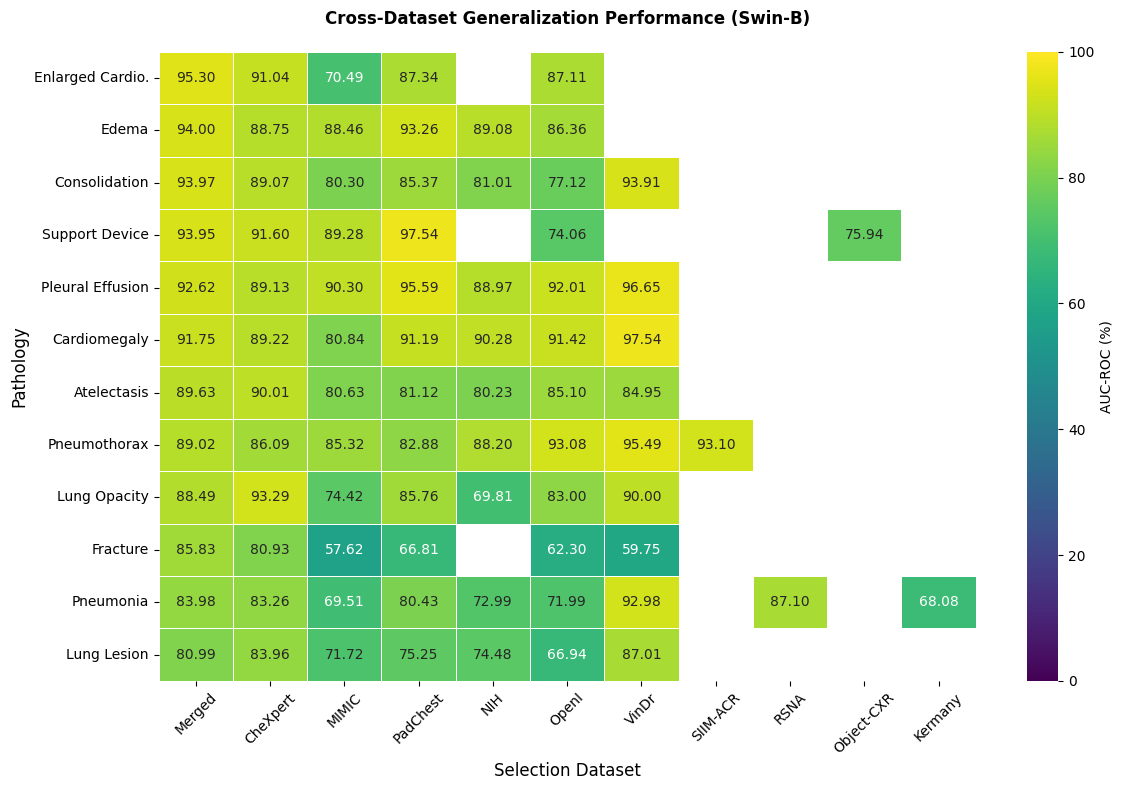

In [7]:
# The 'Dataset' column actually contains the Pathologies. Let's rename it for clarity.
df = df.rename(columns={'Dataset': 'Pathology'})
df = df.set_index('Pathology')
target_datasets = ['Merged', 'CheXpert', 'MIMIC', 'PadChest', 'NIH', 'OpenI', 'VinDr', 'SIIM-ACR', 'RSNA', 'Object-CXR', 'Kermany']

# Filter the dataframe
df_clean = df[target_datasets].copy()

# Convert strings "89,71" to floats 89.71
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').astype(float)

plt.figure(figsize=(12, 8))

# Create the heatmap
ax = sns.heatmap(df_clean, annot=True, fmt=".2f", cmap="viridis", 
                 vmin=0, vmax=100, linewidths=.5, cbar_kws={'label': 'AUC-ROC (%)'})

# Styling
plt.title('Cross-Dataset Generalization Performance (Swin-B)', fontsize=12, pad=20, weight='bold')
plt.ylabel('Pathology', fontsize=12)
plt.xlabel('Selection Dataset', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Save the plot
plt.tight_layout()
plt.savefig('generalization_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Datasets Inference Heatmap (F1)

In [8]:
# 1. Load the data
# We assume the file is named 'inference.csv' and uses ';' as delimiter
df = pd.read_csv('inferencef1.csv', delimiter=';')
df['Dataset'] = df['Dataset'].replace({'Enlarged Cardiomediastinum': 'Enlarged Cardio.'})
df = df.rename(columns={'Object': 'Object-CXR'})
df = df.sort_values(by='Merged', ascending=False)
df

,Dataset,CheXpert,MIMIC,PadChest,NIH,OpenI,VinDr,SIIM-ACR,RSNA,Object-CXR,Kermany,Merged
4,Enlarged Cardio.,"89,11","13,00","44,57",NaN,"43,54",NaN,NaN,NaN,NaN,NaN,"83,60"
11,Support Device,"89,48","69,78","82,06",NaN,"53,00",NaN,NaN,NaN,"71,48",NaN,"81,99"
2,Consolidation,"82,89","22,23","16,32","25,66","39,94","37,24",NaN,NaN,NaN,NaN,"75,87"
8,Pleural Effusion,"81,71","69,03","65,08","56,96","48,69","74,66",NaN,NaN,NaN,NaN,"74,53"
7,Lung Opacity,"91,40","48,02","52,30","40,50","52,15","48,77",NaN,NaN,NaN,NaN,"72,59"
1,Cardiomegaly,"85,28","50,20","55,31","35,19","58,03","76,82",NaN,NaN,NaN,NaN,"72,27"
3,Edema,"79,79","50,85","26,34","23,38","43,43",NaN,NaN,NaN,NaN,NaN,"71,17"
0,Atelectasis,"86,01","52,67","36,50","40,47","42,65","19,83",NaN,NaN,NaN,NaN,"70,69"
5,Fracture,"57,41","5,33","11,16",NaN,"10,63","2,90",NaN,NaN,NaN,NaN,"51,27"
10,Pneumothorax,"53,82","39,57","28,54","47,84","33,52","42,86","75,96",NaN,NaN,NaN,"48,99"


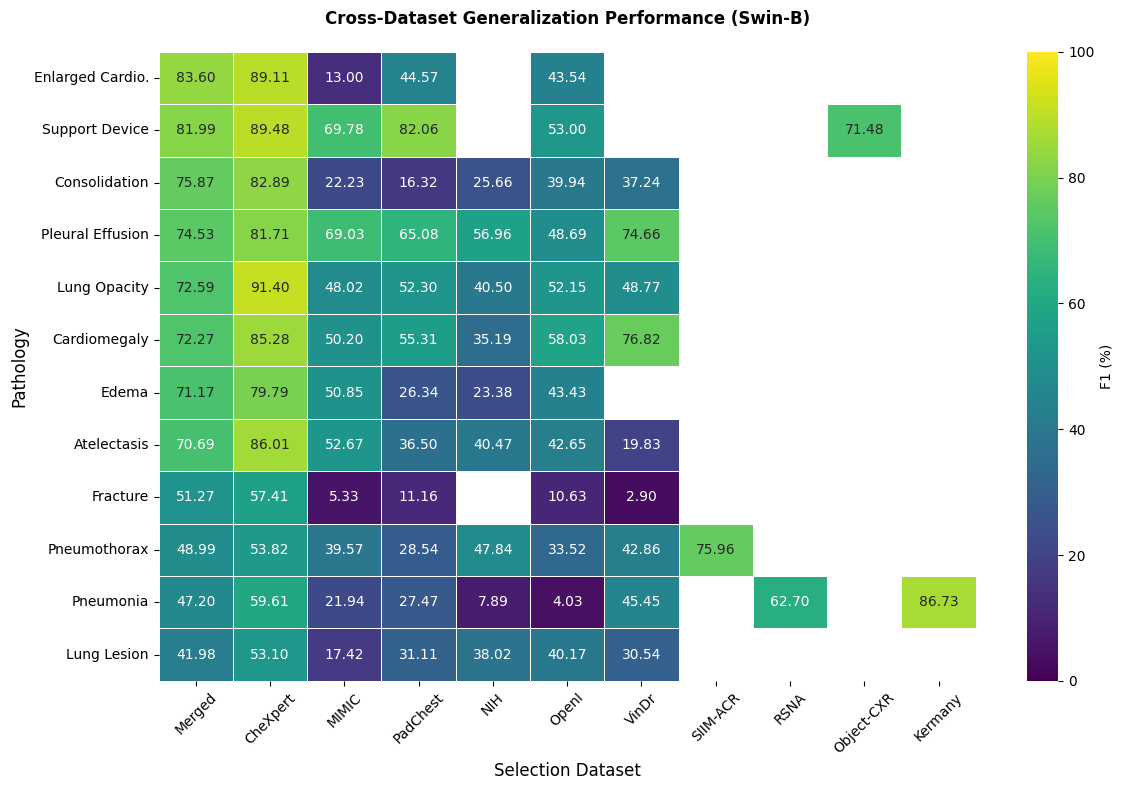

In [9]:
# The 'Dataset' column actually contains the Pathologies. Let's rename it for clarity.
df = df.rename(columns={'Dataset': 'Pathology'})
df = df.set_index('Pathology')
target_datasets = ['Merged', 'CheXpert', 'MIMIC', 'PadChest', 'NIH', 'OpenI', 'VinDr', 'SIIM-ACR', 'RSNA', 'Object-CXR', 'Kermany']

# Filter the dataframe
df_clean = df[target_datasets].copy()

# Convert strings "89,71" to floats 89.71
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').astype(float)

plt.figure(figsize=(12, 8))

# Create the heatmap
ax = sns.heatmap(df_clean, annot=True, fmt=".2f", cmap="viridis", 
                 vmin=0, vmax=100, linewidths=.5, cbar_kws={'label': 'F1 (%)'})

# Styling
plt.title('Cross-Dataset Generalization Performance (Swin-B)', fontsize=12, pad=20, weight='bold')
plt.ylabel('Pathology', fontsize=12)
plt.xlabel('Selection Dataset', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Save the plot
plt.tight_layout()
plt.savefig('generalization_heatmap_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# MIMIC Datasets Further Analysis

In [2]:
def safe_collate(batch):
    batch = [b for b in batch if b is not None]

    imgs = []
    labs = []

    for b in batch:
        img = torch.tensor(b["img"])
        lab = torch.tensor(b["lab"])

        # Ensure image is 3-channel
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)  # grayscale → RGB
        elif img.ndim == 2:
            img = img.unsqueeze(0).repeat(3, 1, 1)  # 2D → 3D RGB
        elif img.shape[0] == 3:
            pass  # already RGB
        else:
            raise ValueError(f"Unexpected image shape: {img.shape}")

        imgs.append(img)
        labs.append(lab)

    return {
        "img": torch.stack(imgs),
        "lab": torch.stack(labs),
        "idx": [b["idx"] for b in batch],
    }

In [20]:
model_paths = {
    "SwinB": "/home/varrel/image_model_dict/final/fixed_swinb_effusion_model_epoch5.pth",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(model_name, path):
    """Load the correct architecture (DenseNet121 or Swin-B) with 1 output."""
    
    if model_name == "DenseNet":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        model = models.densenet121(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, 1)

    elif model_name == "SwinB":
        weights = models.Swin_B_Weights.IMAGENET1K_V1
        model = models.swin_b(weights=weights)
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, 1)

    elif model_name == "ResNet":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, 1)

    elif model_name == "VitB":
        weights = models.ViT_B_16_Weights.IMAGENET1K_V1
        model = models.vit_b_16(weights=weights)
        in_features = model.heads[-1].in_features
        model.heads = nn.Linear(in_features, 1)

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    # Load checkpoint
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model = model.to(device)
    model.eval()
    return model

models_dict = { name: load_model(name, path) for name, path in model_paths.items() }

In [22]:
csvpath=r"/home/varrel/imaging/physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-chexpert.csv"
metacsvpath=r"/home/varrel/imaging/physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-metadata.csv"
splitpath=r"/home/varrel/imaging/physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-split.csv"

split = pd.read_csv(splitpath)
csv = pd.read_csv(csvpath)
csv['Pleural Effusion'].value_counts(dropna=False)

Pleural Effusion
 NaN    140555
 1.0     54300
 0.0     27158
-1.0      5814
Name: count, dtype: int64

In [5]:
csv

,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000764,57375967,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227822,19999442,58708861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
227823,19999733,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
227824,19999987,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
227825,19999987,58621812,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [24]:
class XRVCorrectionDataset(torch.utils.data.Dataset):
    """
    Wraps standard XRV datasets (range -1024 to 1024) and 
    rescales them to [0, 1] to match PNGFolderDataset.
    Exposes essential attributes for MergeDataset.
    """
    def __init__(self, dataset):
        self.dataset = dataset
        
        # CRITICAL: Forward metadata so MergeDataset can see it!
        if hasattr(dataset, 'csv'):
            self.csv = dataset.csv
        if hasattr(dataset, 'pathologies'):
            self.pathologies = dataset.pathologies
        if hasattr(dataset, 'labels'):
            self.labels = dataset.labels  # <--- This was missing before!
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img = sample['img'] # numpy array, usually -1024 to 1024
        
        # Rescale [-1024, 1024] -> [0, 1]
        img = (img + 1024) / 2048.0
        
        # Clip to ensure safety
        img = np.clip(img, 0, 1)
        
        # Ensure 3-channel dimension if missing
        if img.ndim == 2:
            img = np.expand_dims(img, 0)
            
        sample['img'] = img
        return sample

d_mimic_sel_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)
d_mimic_train_raw = xrv.datasets.MIMIC_Dataset(imgpath="/home/varrel/imaging/all_images/MIMIC_dataset/images_all/preprocess7",
                                         csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_train_split_xrv.csv",
                                         metacsvpath="/home/varrel/imaging/all_images/MIMIC_dataset/mimic-cxr-2.0.0-metadata.csv",
                                         views=["PA","AP"], unique_patients=False)

# 2. Relabel BEFORE Wrapping (Relabel works on the .csv attribute)
classes = ['Effusion']
xrv.datasets.relabel_dataset(classes, d_mimic_sel_raw)
xrv.datasets.relabel_dataset(classes, d_mimic_train_raw)

# 3. Apply Correction Wrapper (Force XRV to [0, 1] range)
d_mimic_selection = XRVCorrectionDataset(d_mimic_sel_raw)
d_mimic_train = XRVCorrectionDataset(d_mimic_sel_raw)

dmerge_selection = xrv.datasets.MergeDataset([
    d_mimic_train_raw, d_mimic_selection, 
])
selection_loader = torch.utils.data.DataLoader(dmerge_selection, batch_size=16, shuffle=False, num_workers=8, collate_fn=safe_collate)

{np.str_('Pneumothorax'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Cardiomegaly'), np.str_('Pleural Other'), np.str_('Consolidation'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Enlarged Cardiomediastinum'), np.str_('Atelectasis')} will be dropped
{np.str_('Pneumothorax'), np.str_('Lung Lesion'), np.str_('Support Devices'), np.str_('Cardiomegaly'), np.str_('Pleural Other'), np.str_('Consolidation'), np.str_('Fracture'), np.str_('Pneumonia'), np.str_('Edema'), np.str_('Lung Opacity'), np.str_('Enlarged Cardiomediastinum'), np.str_('Atelectasis')} will be dropped


In [25]:
model = models_dict['SwinB'] 
loader = selection_loader

all_probs = []

model.eval()
with torch.no_grad():
    for batch in tqdm(loader, desc="Running Inference"):
        inputs = batch["img"].to(device)
        
        # Forward pass
        outputs = model(inputs).squeeze(1)
        outputs = torch.clamp(outputs, min=-20, max=20)
        probs = torch.sigmoid(outputs).cpu().numpy()
        
        all_probs.extend(probs)

# Convert to numpy array for easier handling
all_probs = np.array(all_probs)
print(f"Total predictions generated: {len(all_probs)}")

Running Inference: 100%|██████████| 13597/13597 [11:24<00:00, 19.86it/s]

Total predictions generated: 217542


In [29]:
df_results = dmerge_selection.csv.copy()

# 2. Safety Check: Ensure lengths match
if len(df_results) != len(all_probs):
    print(f"WARNING: Mismatch! DataFrame has {len(df_results)} rows but we have {len(all_probs)} predictions.")
else:
    print("Great! DataFrame length matches prediction length.")

    # 3. Add the new column
    df_results['prob_effusion'] = all_probs

    # 4. Filter to keep only what you asked for
    # (Assuming columns 'subject_id' and 'study_id' exist in the MIMIC csv)
    final_df = df_results[['subject_id', 'study_id', 'prob_effusion']]

    # 5. Save to CSV
    save_path = "mimic_selection_with_probs_effusion.csv"
    final_df.to_csv(save_path, index=False)
    print(f"Saved results to {save_path}")

Great! DataFrame length matches prediction length.
Saved results to mimic_selection_with_probs_effusion.csv


### Cardiomegaly (No-Weight)

In [82]:
df_probs = pd.read_csv("mimic_selection_with_probs_cardiomegaly.csv")
df_original = csv

merged_df = pd.merge(df_probs, df_original, on=["subject_id", "study_id"], how="inner")
TARGET_LABEL = "Cardiomegaly"

merged_df['plot_label'] = merged_df[TARGET_LABEL].astype(str)
merged_df['plot_label'] = merged_df['plot_label'].replace('nan', 'NaN')

print(f"Merged Data Shape: {merged_df.shape}")
print("Label Counts:\n", merged_df['plot_label'].value_counts())

Merged Data Shape: (217542, 18)
Label Counts:
 plot_label
NaN     154886
1.0      42258
0.0      14664
-1.0      5734
Name: count, dtype: int64


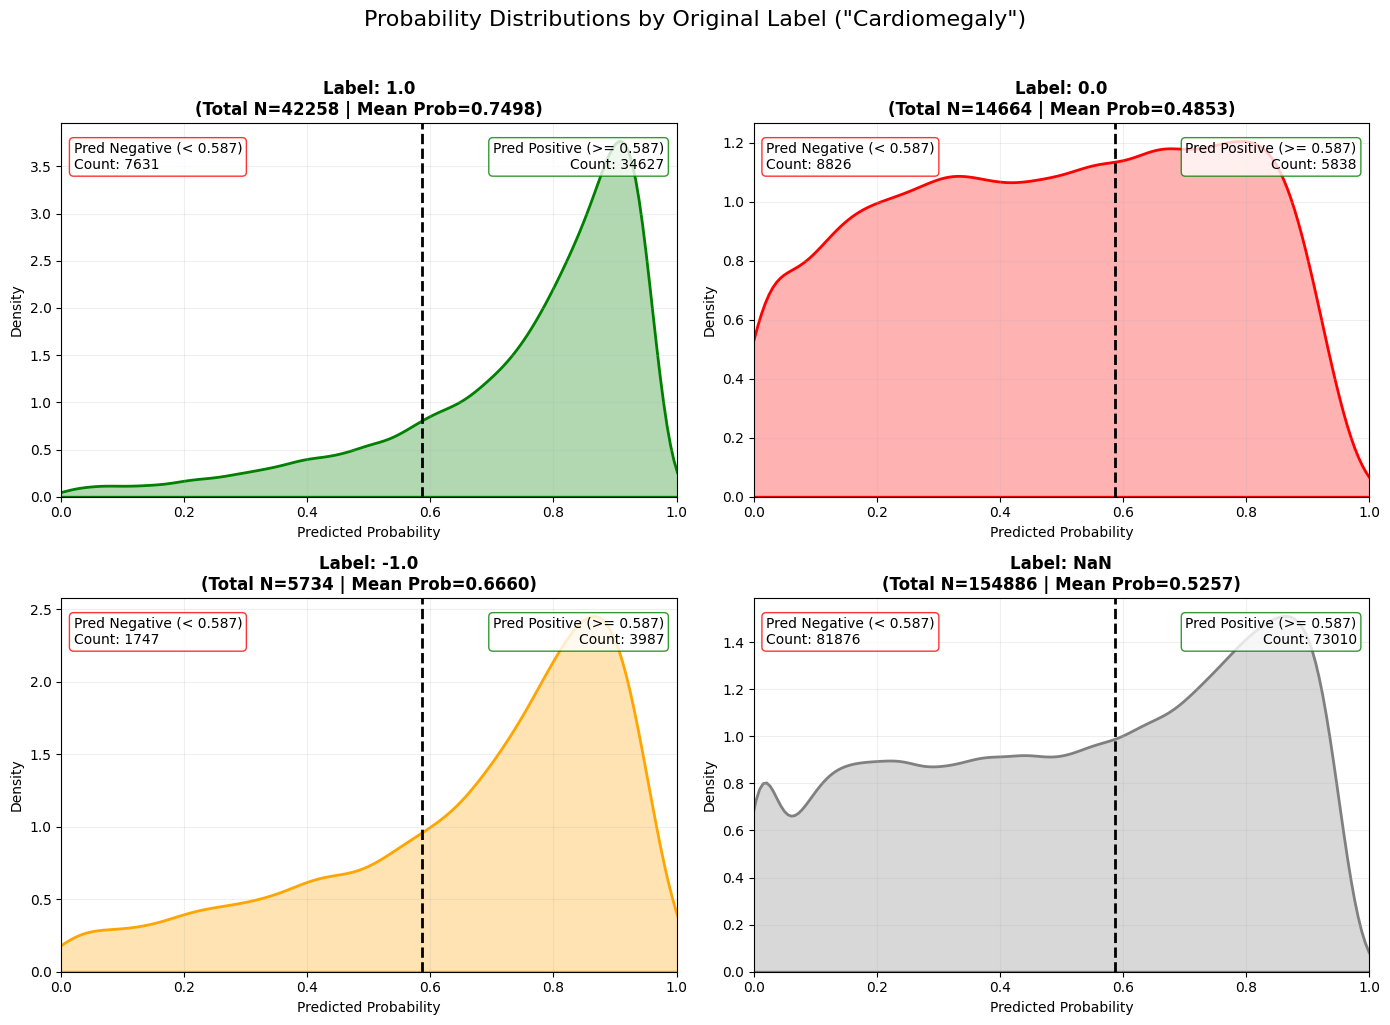

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
OPTIMAL_THRESH = 0.587
categories = ["1.0", "0.0", "-1.0", "NaN"]
colors = ["green", "red", "orange", "gray"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plt.suptitle(f'Probability Distributions by Original Label ("{TARGET_LABEL}")', fontsize=16, y=1.02)

for i, cat in enumerate(categories):
    ax = axes[i]
    
    # Filter data for this specific category
    subset = merged_df[merged_df['plot_label'] == cat]
    probs = subset['prob_cardiomegaly']
    
    # Calculate stats
    n_samples = len(subset)
    mean_prob = probs.mean() if n_samples > 0 else 0
    
    # --- NEW: Calculate counts based on threshold ---
    n_pos_pred = (probs >= OPTIMAL_THRESH).sum() # Classified as Positive
    n_neg_pred = (probs < OPTIMAL_THRESH).sum()  # Classified as Negative
    # ------------------------------------------------
    
    # Plot Density (KDE)
    if n_samples > 1:
        sns.kdeplot(
            data=subset, 
            x="prob_cardiomegaly", 
            ax=ax, 
            fill=True, 
            color=colors[i], 
            linewidth=2,
            alpha=0.3
        )
    elif n_samples == 1:
        ax.axvline(probs.iloc[0], color=colors[i], linewidth=3, label='Single Sample')
    else:
        ax.text(0.5, 0.5, "Not enough data", ha='center')

    # Rugplot for small datasets
    if n_samples > 0 and n_samples < 500:
        sns.rugplot(data=subset, x="prob_cardiomegaly", ax=ax, color=colors[i], height=0.1)
    
    # Formatting
    ax.set_title(f"Label: {cat}\n(Total N={n_samples} | Mean Prob={mean_prob:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    
    # --- NEW: Threshold Line & Text Annotations ---
    if n_samples > 0:
        # 1. Vertical Line at Optimal Threshold
        ax.axvline(OPTIMAL_THRESH, color='black', linestyle='--', linewidth=2, label=f'Thresh ({OPTIMAL_THRESH})')
        
        # 2. Text Box: Classified Negative (Left)
        ax.text(0.02, 0.95, f'Pred Negative (< {OPTIMAL_THRESH})\nCount: {n_neg_pred}', 
                transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
        
        # 3. Text Box: Classified Positive (Right)
        ax.text(0.98, 0.95, f'Pred Positive (>= {OPTIMAL_THRESH})\nCount: {n_pos_pred}', 
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))
    # ----------------------------------------------
    
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Cardiomegaly Weighted

In [84]:
df_probs = pd.read_csv("mimic_selection_with_probs_cardiomegaly_weighted.csv")
df_original = csv

merged_df = pd.merge(df_probs, df_original, on=["subject_id", "study_id"], how="inner")
TARGET_LABEL = "Cardiomegaly"

merged_df['plot_label'] = merged_df[TARGET_LABEL].astype(str)
merged_df['plot_label'] = merged_df['plot_label'].replace('nan', 'NaN')

print(f"Merged Data Shape: {merged_df.shape}")
print("Label Counts:\n", merged_df['plot_label'].value_counts())

Merged Data Shape: (217542, 18)
Label Counts:
 plot_label
NaN     154886
1.0      42258
0.0      14664
-1.0      5734
Name: count, dtype: int64


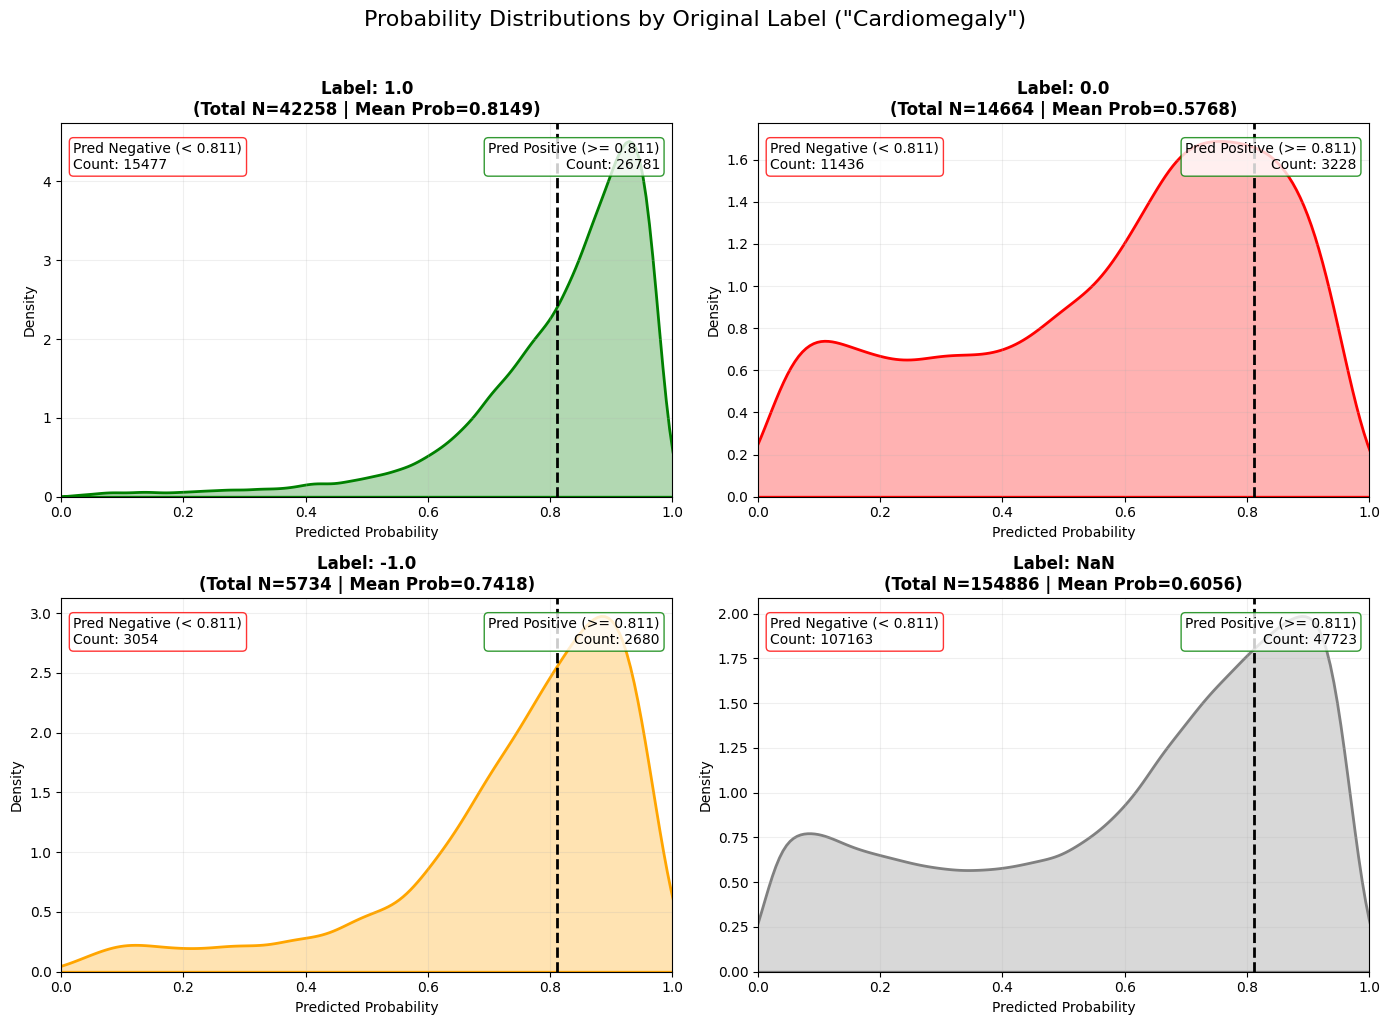

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
OPTIMAL_THRESH = 0.811
categories = ["1.0", "0.0", "-1.0", "NaN"]
colors = ["green", "red", "orange", "gray"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plt.suptitle(f'Probability Distributions by Original Label ("{TARGET_LABEL}")', fontsize=16, y=1.02)

for i, cat in enumerate(categories):
    ax = axes[i]
    
    # Filter data for this specific category
    subset = merged_df[merged_df['plot_label'] == cat]
    probs = subset['prob_cardiomegaly']
    
    # Calculate stats
    n_samples = len(subset)
    mean_prob = probs.mean() if n_samples > 0 else 0
    
    # --- NEW: Calculate counts based on threshold ---
    n_pos_pred = (probs >= OPTIMAL_THRESH).sum() # Classified as Positive
    n_neg_pred = (probs < OPTIMAL_THRESH).sum()  # Classified as Negative
    # ------------------------------------------------
    
    # Plot Density (KDE)
    if n_samples > 1:
        sns.kdeplot(
            data=subset, 
            x="prob_cardiomegaly", 
            ax=ax, 
            fill=True, 
            color=colors[i], 
            linewidth=2,
            alpha=0.3
        )
    elif n_samples == 1:
        ax.axvline(probs.iloc[0], color=colors[i], linewidth=3, label='Single Sample')
    else:
        ax.text(0.5, 0.5, "Not enough data", ha='center')

    # Rugplot for small datasets
    if n_samples > 0 and n_samples < 500:
        sns.rugplot(data=subset, x="prob_cardiomegaly", ax=ax, color=colors[i], height=0.1)
    
    # Formatting
    ax.set_title(f"Label: {cat}\n(Total N={n_samples} | Mean Prob={mean_prob:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    
    # --- NEW: Threshold Line & Text Annotations ---
    if n_samples > 0:
        # 1. Vertical Line at Optimal Threshold
        ax.axvline(OPTIMAL_THRESH, color='black', linestyle='--', linewidth=2, label=f'Thresh ({OPTIMAL_THRESH})')
        
        # 2. Text Box: Classified Negative (Left)
        ax.text(0.02, 0.95, f'Pred Negative (< {OPTIMAL_THRESH})\nCount: {n_neg_pred}', 
                transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
        
        # 3. Text Box: Classified Positive (Right)
        ax.text(0.98, 0.95, f'Pred Positive (>= {OPTIMAL_THRESH})\nCount: {n_pos_pred}', 
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))
    # ----------------------------------------------
    
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Enlarged (No Weight)

In [11]:
df_probs = pd.read_csv("mimic_selection_with_probs_enlarged.csv")
df_original = csv

merged_df = pd.merge(df_probs, df_original, on=["subject_id", "study_id"], how="inner")
TARGET_LABEL = "Enlarged Cardiomediastinum"

merged_df['plot_label'] = merged_df[TARGET_LABEL].astype(str)
merged_df['plot_label'] = merged_df['plot_label'].replace('nan', 'NaN')

print(f"Merged Data Shape: {merged_df.shape}")
print("Label Counts:\n", merged_df['plot_label'].value_counts())

Merged Data Shape: (217542, 18)
Label Counts:
 plot_label
NaN     196955
-1.0      8900
1.0       6802
0.0       4885
Name: count, dtype: int64


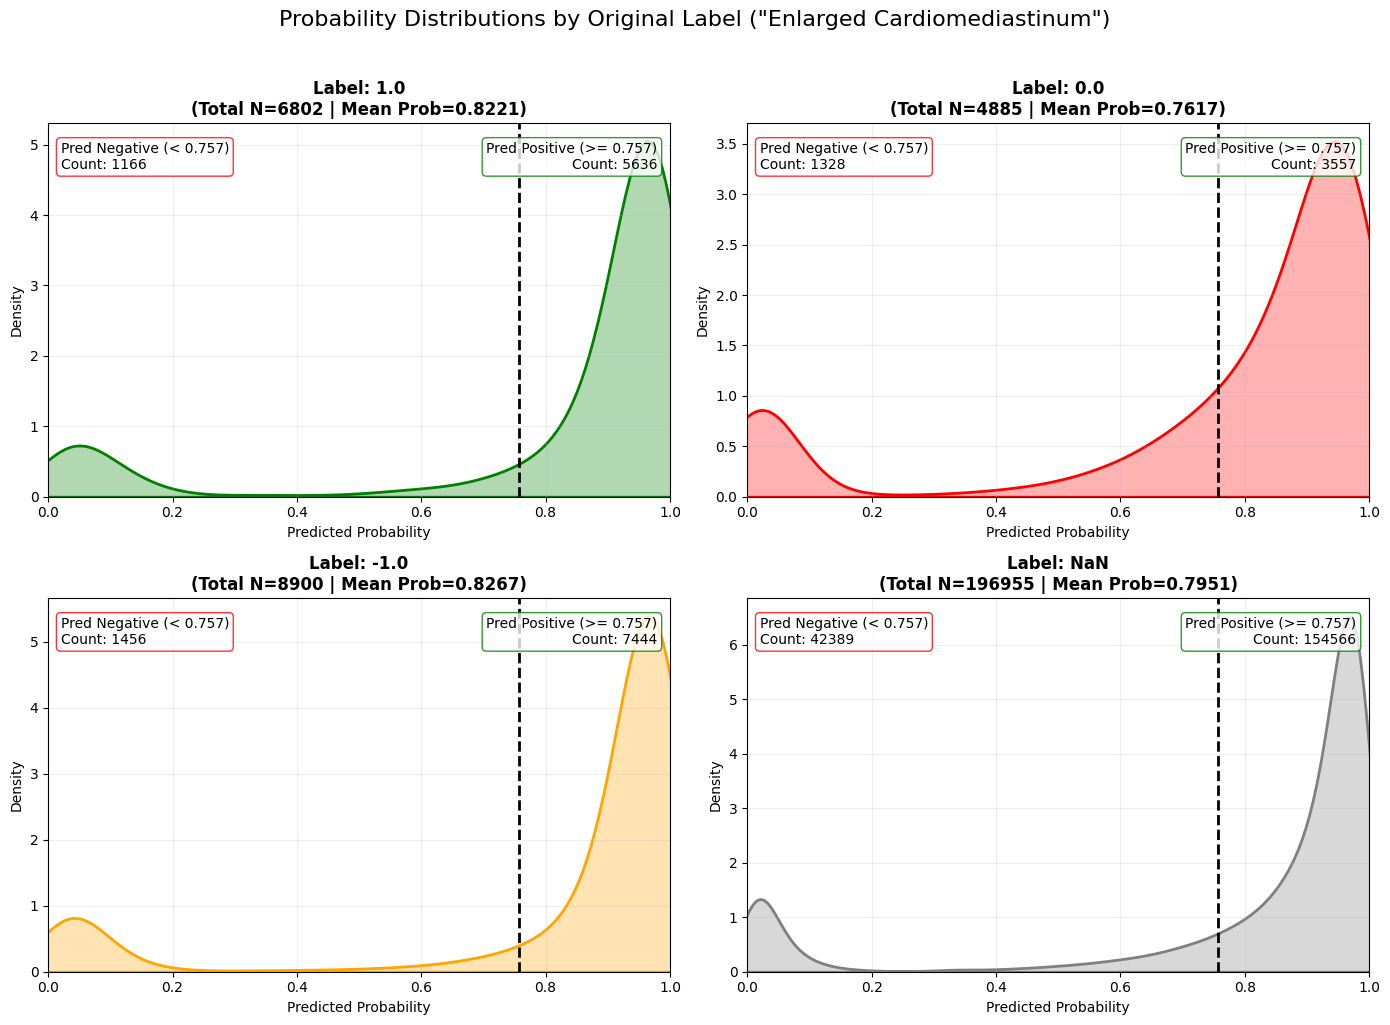

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
OPTIMAL_THRESH = 0.757
categories = ["1.0", "0.0", "-1.0", "NaN"]
colors = ["green", "red", "orange", "gray"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plt.suptitle(f'Probability Distributions by Original Label ("{TARGET_LABEL}")', fontsize=16, y=1.02)

for i, cat in enumerate(categories):
    ax = axes[i]
    
    # Filter data for this specific category
    subset = merged_df[merged_df['plot_label'] == cat]
    probs = subset['prob_enlarged']
    
    # Calculate stats
    n_samples = len(subset)
    mean_prob = probs.mean() if n_samples > 0 else 0
    
    # --- NEW: Calculate counts based on threshold ---
    n_pos_pred = (probs >= OPTIMAL_THRESH).sum() # Classified as Positive
    n_neg_pred = (probs < OPTIMAL_THRESH).sum()  # Classified as Negative
    # ------------------------------------------------
    
    # Plot Density (KDE)
    if n_samples > 1:
        sns.kdeplot(
            data=subset, 
            x="prob_enlarged", 
            ax=ax, 
            fill=True, 
            color=colors[i], 
            linewidth=2,
            alpha=0.3
        )
    elif n_samples == 1:
        ax.axvline(probs.iloc[0], color=colors[i], linewidth=3, label='Single Sample')
    else:
        ax.text(0.5, 0.5, "Not enough data", ha='center')

    # Rugplot for small datasets
    if n_samples > 0 and n_samples < 500:
        sns.rugplot(data=subset, x="prob_enlarged", ax=ax, color=colors[i], height=0.1)
    
    # Formatting
    ax.set_title(f"Label: {cat}\n(Total N={n_samples} | Mean Prob={mean_prob:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    
    # --- NEW: Threshold Line & Text Annotations ---
    if n_samples > 0:
        # 1. Vertical Line at Optimal Threshold
        ax.axvline(OPTIMAL_THRESH, color='black', linestyle='--', linewidth=2, label=f'Thresh ({OPTIMAL_THRESH})')
        
        # 2. Text Box: Classified Negative (Left)
        ax.text(0.02, 0.95, f'Pred Negative (< {OPTIMAL_THRESH})\nCount: {n_neg_pred}', 
                transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
        
        # 3. Text Box: Classified Positive (Right)
        ax.text(0.98, 0.95, f'Pred Positive (>= {OPTIMAL_THRESH})\nCount: {n_pos_pred}', 
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))
    # ----------------------------------------------
    
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Enlarged Weighted

In [26]:
df_probs = pd.read_csv("mimic_selection_with_probs_enlarged_weighted.csv")
df_original = csv

merged_df = pd.merge(df_probs, df_original, on=["subject_id", "study_id"], how="inner")
TARGET_LABEL = "Enlarged Cardiomediastinum"

merged_df['plot_label'] = merged_df[TARGET_LABEL].astype(str)
merged_df['plot_label'] = merged_df['plot_label'].replace('nan', 'NaN')

print(f"Merged Data Shape: {merged_df.shape}")
print("Label Counts:\n", merged_df['plot_label'].value_counts())

Merged Data Shape: (217542, 18)
Label Counts:
 plot_label
NaN     196955
-1.0      8900
1.0       6802
0.0       4885
Name: count, dtype: int64


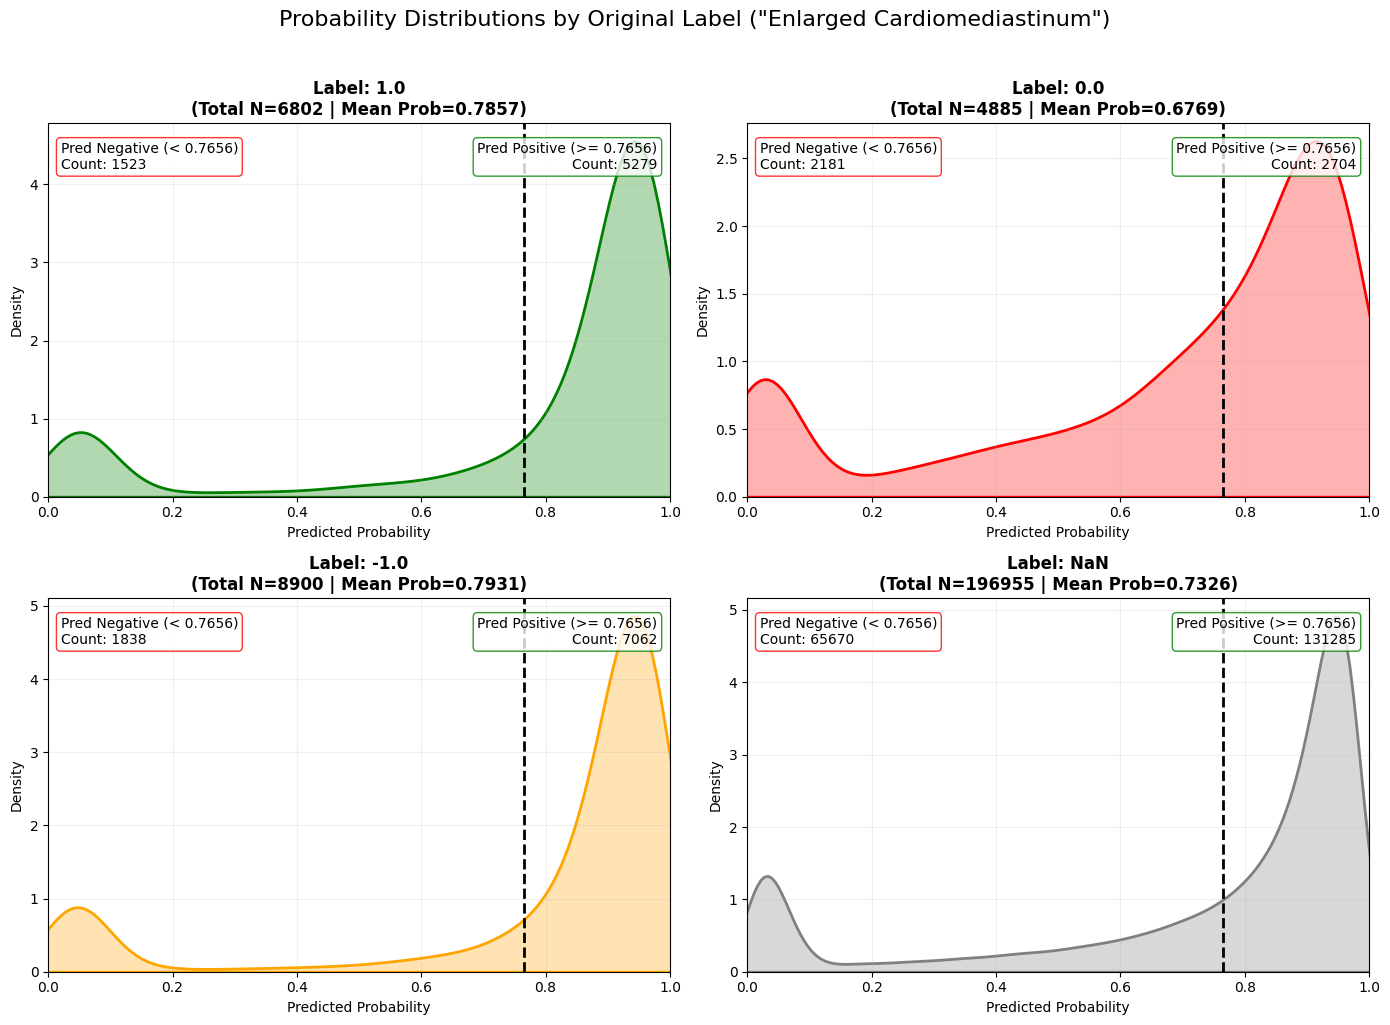

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
OPTIMAL_THRESH = 0.7656
categories = ["1.0", "0.0", "-1.0", "NaN"]
colors = ["green", "red", "orange", "gray"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plt.suptitle(f'Probability Distributions by Original Label ("{TARGET_LABEL}")', fontsize=16, y=1.02)

for i, cat in enumerate(categories):
    ax = axes[i]
    
    # Filter data for this specific category
    subset = merged_df[merged_df['plot_label'] == cat]
    probs = subset['prob_enlarged']
    
    # Calculate stats
    n_samples = len(subset)
    mean_prob = probs.mean() if n_samples > 0 else 0
    
    # --- NEW: Calculate counts based on threshold ---
    n_pos_pred = (probs >= OPTIMAL_THRESH).sum() # Classified as Positive
    n_neg_pred = (probs < OPTIMAL_THRESH).sum()  # Classified as Negative
    # ------------------------------------------------
    
    # Plot Density (KDE)
    if n_samples > 1:
        sns.kdeplot(
            data=subset, 
            x="prob_enlarged", 
            ax=ax, 
            fill=True, 
            color=colors[i], 
            linewidth=2,
            alpha=0.3
        )
    elif n_samples == 1:
        ax.axvline(probs.iloc[0], color=colors[i], linewidth=3, label='Single Sample')
    else:
        ax.text(0.5, 0.5, "Not enough data", ha='center')

    # Rugplot for small datasets
    if n_samples > 0 and n_samples < 500:
        sns.rugplot(data=subset, x="prob_enlarged", ax=ax, color=colors[i], height=0.1)
    
    # Formatting
    ax.set_title(f"Label: {cat}\n(Total N={n_samples} | Mean Prob={mean_prob:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    
    # --- NEW: Threshold Line & Text Annotations ---
    if n_samples > 0:
        # 1. Vertical Line at Optimal Threshold
        ax.axvline(OPTIMAL_THRESH, color='black', linestyle='--', linewidth=2, label=f'Thresh ({OPTIMAL_THRESH})')
        
        # 2. Text Box: Classified Negative (Left)
        ax.text(0.02, 0.95, f'Pred Negative (< {OPTIMAL_THRESH})\nCount: {n_neg_pred}', 
                transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
        
        # 3. Text Box: Classified Positive (Right)
        ax.text(0.98, 0.95, f'Pred Positive (>= {OPTIMAL_THRESH})\nCount: {n_pos_pred}', 
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))
    # ----------------------------------------------
    
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Effusion (No Weight)

In [32]:
df_probs = pd.read_csv("mimic_selection_with_probs_effusion.csv")
df_original = csv

merged_df = pd.merge(df_probs, df_original, on=["subject_id", "study_id"], how="inner")
TARGET_LABEL = "Pleural Effusion"

merged_df['plot_label'] = merged_df[TARGET_LABEL].astype(str)
merged_df['plot_label'] = merged_df['plot_label'].replace('nan', 'NaN')

print(f"Merged Data Shape: {merged_df.shape}")
print("Label Counts:\n", merged_df['plot_label'].value_counts())

Merged Data Shape: (217542, 18)
Label Counts:
 plot_label
NaN     136119
1.0      51244
0.0      24667
-1.0      5512
Name: count, dtype: int64


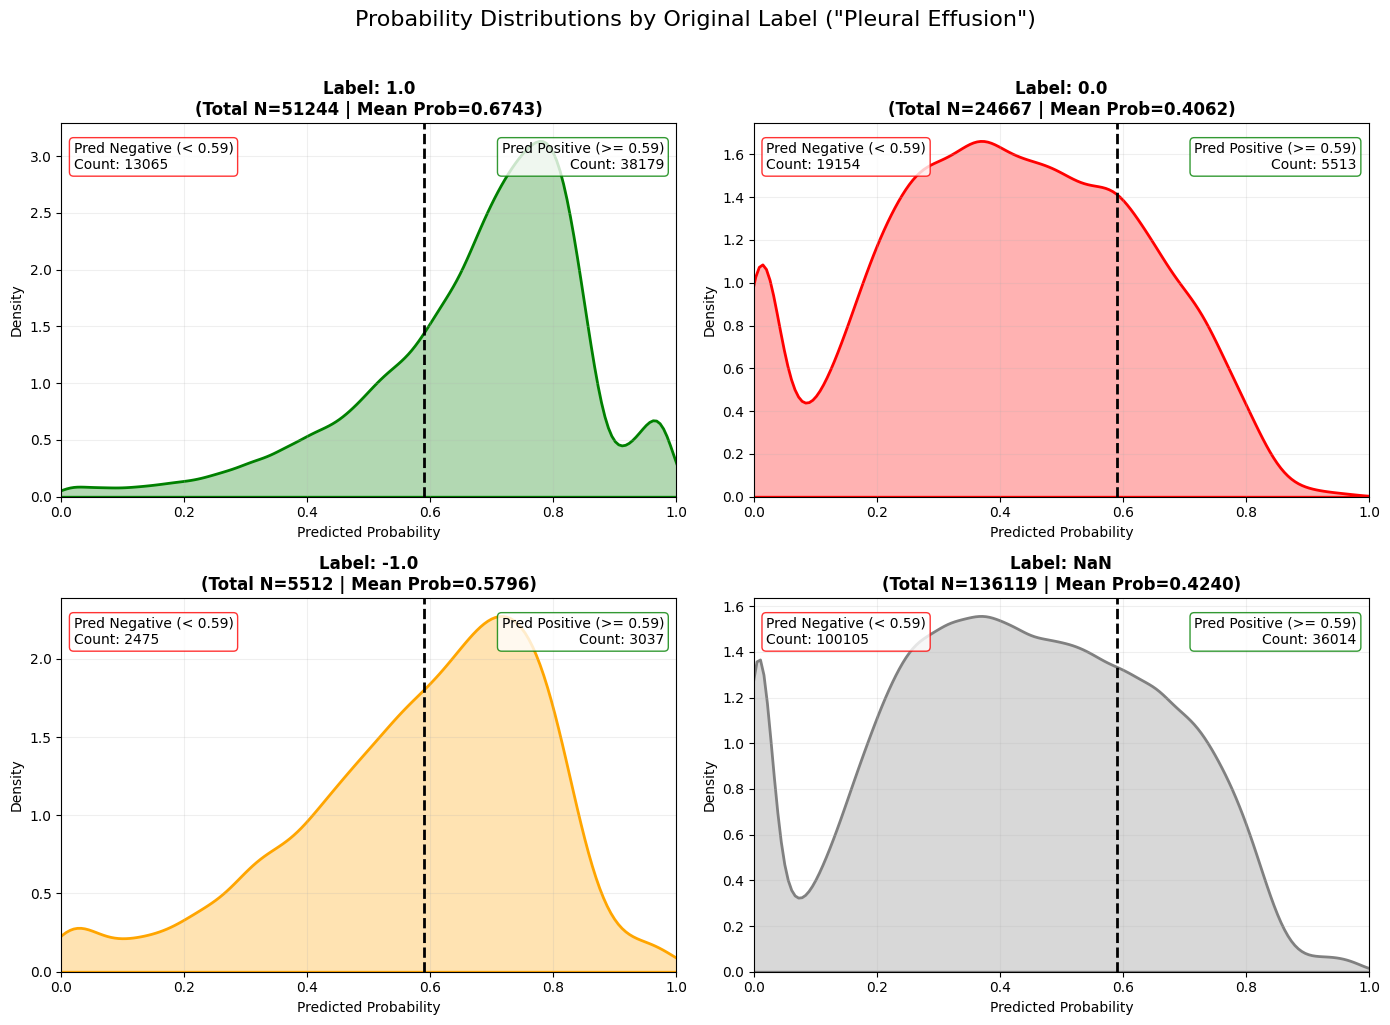

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
OPTIMAL_THRESH = 0.590
categories = ["1.0", "0.0", "-1.0", "NaN"]
colors = ["green", "red", "orange", "gray"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plt.suptitle(f'Probability Distributions by Original Label ("{TARGET_LABEL}")', fontsize=16, y=1.02)

for i, cat in enumerate(categories):
    ax = axes[i]
    
    # Filter data for this specific category
    subset = merged_df[merged_df['plot_label'] == cat]
    probs = subset['prob_effusion']
    
    # Calculate stats
    n_samples = len(subset)
    mean_prob = probs.mean() if n_samples > 0 else 0
    
    # --- NEW: Calculate counts based on threshold ---
    n_pos_pred = (probs >= OPTIMAL_THRESH).sum() # Classified as Positive
    n_neg_pred = (probs < OPTIMAL_THRESH).sum()  # Classified as Negative
    # ------------------------------------------------
    
    # Plot Density (KDE)
    if n_samples > 1:
        sns.kdeplot(
            data=subset, 
            x="prob_effusion", 
            ax=ax, 
            fill=True, 
            color=colors[i], 
            linewidth=2,
            alpha=0.3
        )
    elif n_samples == 1:
        ax.axvline(probs.iloc[0], color=colors[i], linewidth=3, label='Single Sample')
    else:
        ax.text(0.5, 0.5, "Not enough data", ha='center')

    # Rugplot for small datasets
    if n_samples > 0 and n_samples < 500:
        sns.rugplot(data=subset, x="prob_effusion", ax=ax, color=colors[i], height=0.1)
    
    # Formatting
    ax.set_title(f"Label: {cat}\n(Total N={n_samples} | Mean Prob={mean_prob:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    
    # --- NEW: Threshold Line & Text Annotations ---
    if n_samples > 0:
        # 1. Vertical Line at Optimal Threshold
        ax.axvline(OPTIMAL_THRESH, color='black', linestyle='--', linewidth=2, label=f'Thresh ({OPTIMAL_THRESH})')
        
        # 2. Text Box: Classified Negative (Left)
        ax.text(0.02, 0.95, f'Pred Negative (< {OPTIMAL_THRESH})\nCount: {n_neg_pred}', 
                transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
        
        # 3. Text Box: Classified Positive (Right)
        ax.text(0.98, 0.95, f'Pred Positive (>= {OPTIMAL_THRESH})\nCount: {n_pos_pred}', 
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))
    # ----------------------------------------------
    
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Pneumonia (No Weight)

In [17]:
df_probs = pd.read_csv("mimic_selection_with_probs_pneumonia.csv")
df_original = csv

merged_df = pd.merge(df_probs, df_original, on=["subject_id", "study_id"], how="inner")
TARGET_LABEL = "Cardiomegaly"

merged_df['plot_label'] = merged_df[TARGET_LABEL].astype(str)
merged_df['plot_label'] = merged_df['plot_label'].replace('nan', 'NaN')

print(f"Merged Data Shape: {merged_df.shape}")
print("Label Counts:\n", merged_df['plot_label'].value_counts())

Merged Data Shape: (217542, 18)
Label Counts:
 plot_label
NaN     154886
1.0      42258
0.0      14664
-1.0      5734
Name: count, dtype: int64


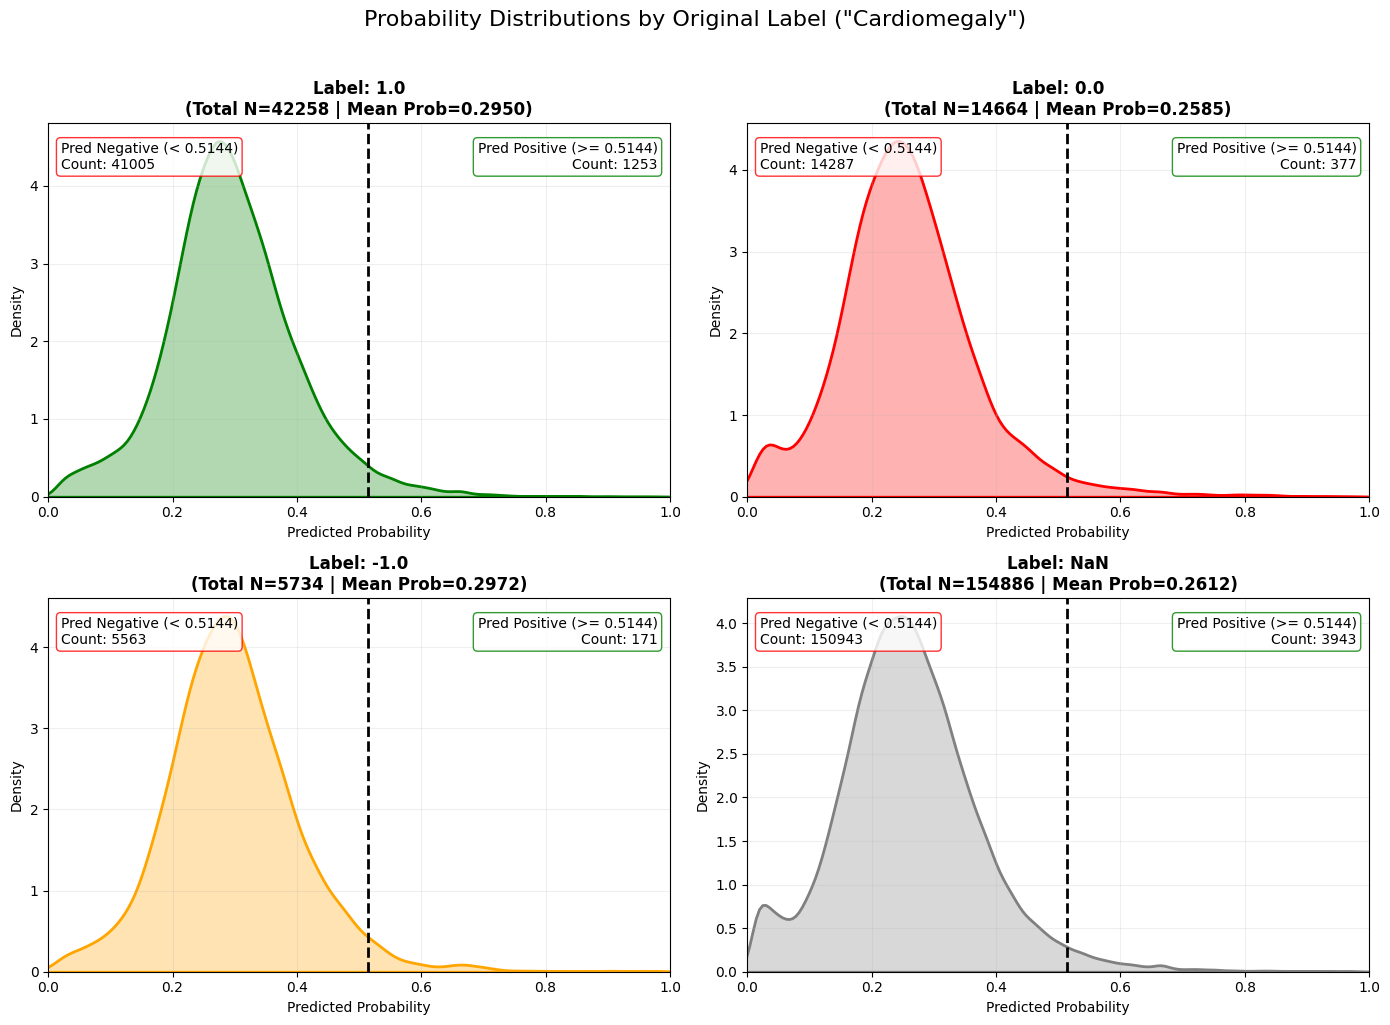

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
OPTIMAL_THRESH = 0.5144
categories = ["1.0", "0.0", "-1.0", "NaN"]
colors = ["green", "red", "orange", "gray"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plt.suptitle(f'Probability Distributions by Original Label ("{TARGET_LABEL}")', fontsize=16, y=1.02)

for i, cat in enumerate(categories):
    ax = axes[i]
    
    # Filter data for this specific category
    subset = merged_df[merged_df['plot_label'] == cat]
    probs = subset['prob_pneumonia']
    
    # Calculate stats
    n_samples = len(subset)
    mean_prob = probs.mean() if n_samples > 0 else 0
    
    # --- NEW: Calculate counts based on threshold ---
    n_pos_pred = (probs >= OPTIMAL_THRESH).sum() # Classified as Positive
    n_neg_pred = (probs < OPTIMAL_THRESH).sum()  # Classified as Negative
    # ------------------------------------------------
    
    # Plot Density (KDE)
    if n_samples > 1:
        sns.kdeplot(
            data=subset, 
            x="prob_pneumonia", 
            ax=ax, 
            fill=True, 
            color=colors[i], 
            linewidth=2,
            alpha=0.3
        )
    elif n_samples == 1:
        ax.axvline(probs.iloc[0], color=colors[i], linewidth=3, label='Single Sample')
    else:
        ax.text(0.5, 0.5, "Not enough data", ha='center')

    # Rugplot for small datasets
    if n_samples > 0 and n_samples < 500:
        sns.rugplot(data=subset, x="prob_pneumonia", ax=ax, color=colors[i], height=0.1)
    
    # Formatting
    ax.set_title(f"Label: {cat}\n(Total N={n_samples} | Mean Prob={mean_prob:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    
    # --- NEW: Threshold Line & Text Annotations ---
    if n_samples > 0:
        # 1. Vertical Line at Optimal Threshold
        ax.axvline(OPTIMAL_THRESH, color='black', linestyle='--', linewidth=2, label=f'Thresh ({OPTIMAL_THRESH})')
        
        # 2. Text Box: Classified Negative (Left)
        ax.text(0.02, 0.95, f'Pred Negative (< {OPTIMAL_THRESH})\nCount: {n_neg_pred}', 
                transform=ax.transAxes, ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
        
        # 3. Text Box: Classified Positive (Right)
        ax.text(0.98, 0.95, f'Pred Positive (>= {OPTIMAL_THRESH})\nCount: {n_pos_pred}', 
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))
    # ----------------------------------------------
    
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

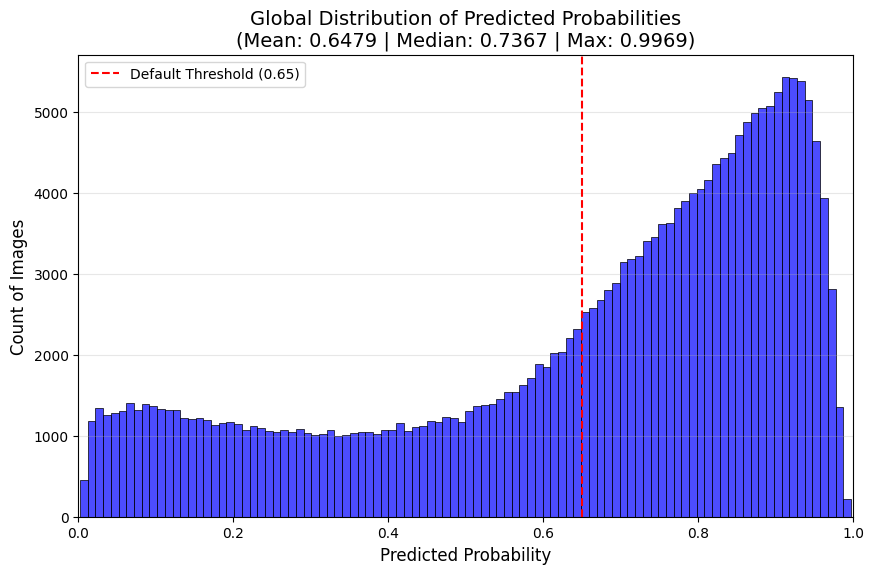

--- Probability Statistics ---
Total Samples: 217542
Min: 0.002061
Max: 0.996867
Samples > 0.5: 160297
Samples > 0.1: 205452


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use your existing probabilities
# If you are using the dataframe:
data = merged_df['prob_cardiomegaly'] 
# If you are using the raw list/array from earlier:
# data = all_probs

plt.figure(figsize=(10, 6))

# Create a Histogram with 100 bins to see fine detail
sns.histplot(data, bins=100, kde=False, color="blue", alpha=0.7)

# Calculate stats for the title/annotation
mean_val = np.mean(data)
median_val = np.median(data)
max_val = np.max(data)
min_val = np.min(data)

# Add labels
plt.title(f"Global Distribution of Predicted Probabilities\n(Mean: {mean_val:.4f} | Median: {median_val:.4f} | Max: {max_val:.4f})", fontsize=14)
plt.xlabel("Predicted Probability", fontsize=12)
plt.ylabel("Count of Images", fontsize=12)
plt.xlim(0, 1)  # Fix x-axis from 0 to 1

# Add a vertical line for your potential threshold (0.5)
plt.axvline(0.65, color='red', linestyle='--', label='Default Threshold (0.65)')
plt.legend()

plt.grid(axis='y', alpha=0.3)
plt.show()

# Print text summary
print("--- Probability Statistics ---")
print(f"Total Samples: {len(data)}")
print(f"Min: {min_val:.6f}")
print(f"Max: {max_val:.6f}")
print(f"Samples > 0.5: {np.sum(data > 0.5)}")
print(f"Samples > 0.1: {np.sum(data > 0.1)}") # Check if there is ANY signal at all

# Model Selection Radar Chart

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

In [12]:
df = pd.read_csv('modelselection.csv', delimiter=';', decimal=',')

categories = list(df.columns[1:])
N = len(categories)

In [13]:
df

,Model,Atelectasis,Atelectasis Std,Atelectasis 95,Cardiomegaly,Cardiomegaly Std,Cardiomegaly 95,Consolidation,Consolidation Std,Consolidation 95,...,Pleural Effusion 95,Pneumonia,Pneumonia Std,Pneumonia 95,Pneumothorax,Pneumothorax Std,Pneumothorax 95,Support Device,Support Device Std,Support Device 95
0,Swin-B,89.64,0.13,0.2548,91.75,0.11,0.2156,93.96,0.11,0.2156,...,0.1960,83.97,0.25,0.4900,89.00,0.26,0.5096,93.96,0.09,0.1764
1,DenseNet121,88.66,0.14,0.2744,90.93,0.12,0.2352,93.31,0.13,0.2548,...,0.2156,82.39,0.27,0.5292,87.12,0.27,0.5292,93.22,0.10,0.1960
2,ResNet50,87.98,0.15,0.2940,90.39,0.13,0.2548,92.70,0.14,0.2744,...,0.2352,79.67,0.30,0.5880,84.97,0.32,0.6272,92.47,0.11,0.2156
3,ViT-16/B,88.48,0.14,0.2744,90.93,0.12,0.2352,93.37,0.13,0.2548,...,0.2156,81.47,0.26,0.5096,85.65,0.29,0.5684,92.27,0.11,0.2156


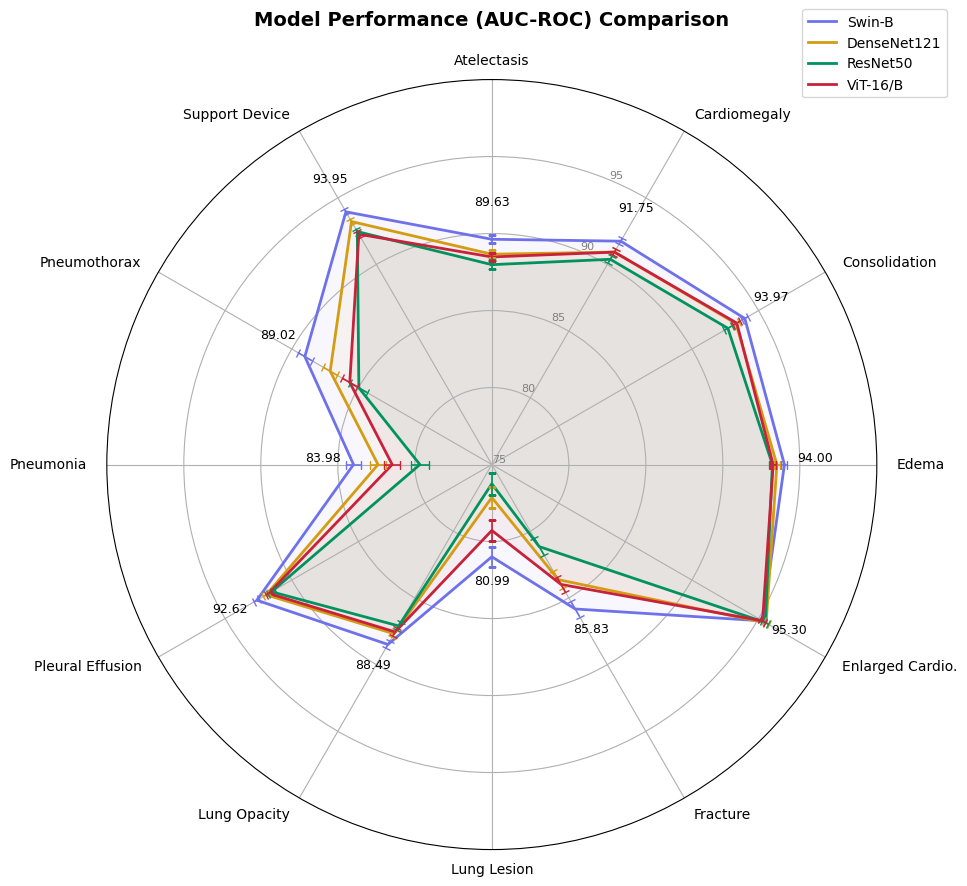

In [41]:
# 1. Identify Categories (Pathologies)
all_cols = df.columns.tolist()
categories = [c for c in all_cols if c != 'Model' and not c.endswith(' Std') and not c.endswith(' 95')]

N = len(categories)

# 2. Setup Angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories)

# Adjust label alignment
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (0, pi):
        label.set_horizontalalignment('center')
    elif 0 < angle < pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')

plt.ylim(75, 100)
plt.yticks([75, 80, 85, 90, 95], ["75", "80", "85", "90", "95"], color="grey", size=8)

colors = ['#6f71ea', '#d49c13', '#00935e', '#c8223a']

# 3. Main Plotting Loop
for i, row in df.iterrows():
    # Get values for this model
    values = row[categories].values.flatten().tolist()
    values += values[:1] # Repeat first value to close the shape
    
    # Current model color
    current_color = colors[i % len(colors)]

    # --- Plot the line ---
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'], color=current_color)
    
    # --- Fill the area ---
    ax.fill(angles, values, color=current_color, alpha=0.05)

    # --- ERROR BARS (Now for ALL models) ---
    # 1. Extract the error values (The "95" columns)
    error_cols = [cat + " 95" for cat in categories]
    errors = row[error_cols].values.flatten().tolist()
    
    # 2. Plot Error Bars
    # We use the same 'current_color' for the error bars so you can tell them apart
    ax.errorbar(angles[:-1], values[:-1], yerr=errors, 
                fmt='none', 
                ecolor=current_color,  # Match the model's color
                capsize=3, 
                elinewidth=1.2,        # Slightly thicker to see against the grid
                zorder=5)

    # --- Text Labels (Keep ONLY for Swin-B to prevent clutter) ---
    if row['Model'] == 'Swin-B':
        for angle, val in zip(angles[:-1], values[:-1]):
            ax.text(angle, val + 2, # Offset slightly more to clear the error bars
                    f"{val:.2f}",
                    horizontalalignment='center',
                    verticalalignment='bottom',
                    size=9,
                    color='black') 

# --- Final Touches ---
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.title("Model Performance (AUC-ROC) Comparison", size=14, pad=20, weight='bold')
plt.savefig('model_selection.png', dpi=300, bbox_inches='tight')
plt.show()

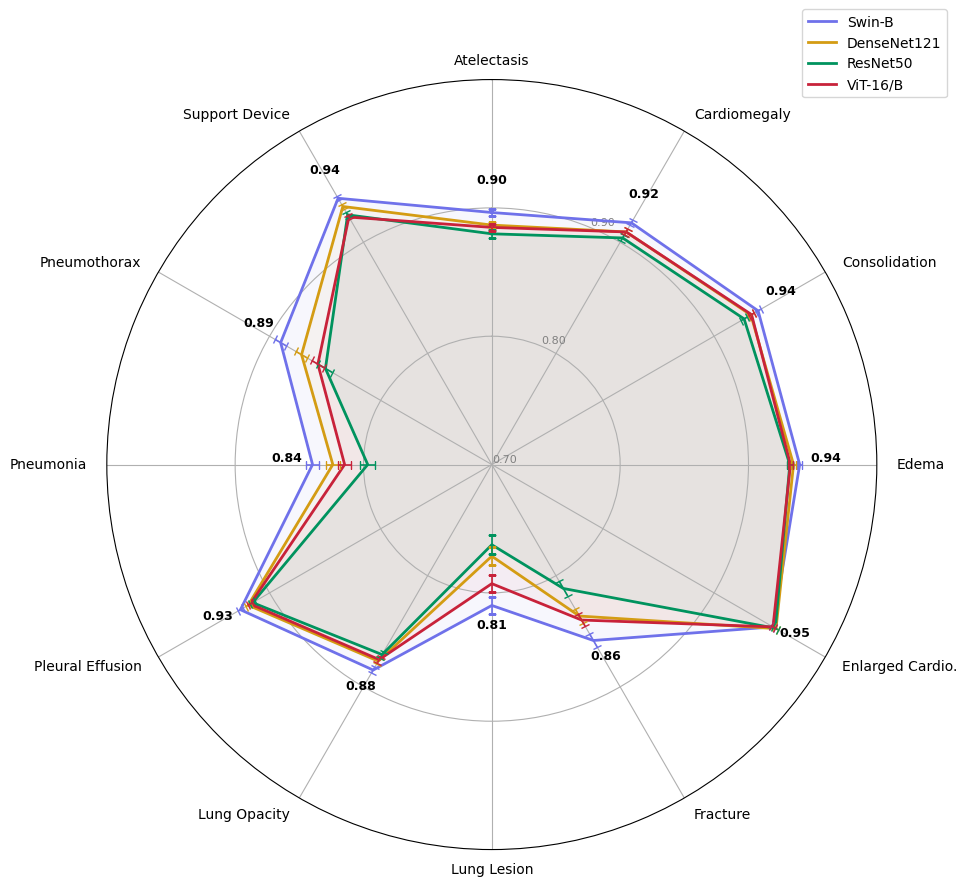

In [7]:
import matplotlib.pyplot as plt
from math import pi
import numpy as np

# 1. Identify Categories (Pathologies)
all_cols = df.columns.tolist()
categories = [c for c in all_cols if c != 'Model' and not c.endswith(' Std') and not c.endswith(' 95')]

N = len(categories)

# 2. Setup Angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories)

# Adjust label alignment
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (0, pi):
        label.set_horizontalalignment('center')
    elif 0 < angle < pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')

# --- ADJUSTED SCALE ---
# Change from (75, 100) to (0.75, 1.0)
plt.ylim(0.70, 1.0) 
ticks = [0.70, 0.80, 0.90]
plt.yticks(ticks, [f"{t:.2f}" for t in ticks], color="grey", size=8)

colors = ['#6f71ea', '#d49c13', '#00935e', '#c8223a']

# 3. Main Plotting Loop
for i, row in df.iterrows():
    # Convert mean values to decimal scale (0-1)
    values = (row[categories].values.flatten() / 100).tolist()
    values += values[:1] 
    
    current_color = colors[i % len(colors)]

    # Plot the line and fill
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'], color=current_color)
    ax.fill(angles, values, color=current_color, alpha=0.05)

    # --- ADJUSTED ERROR BARS ---
    error_cols = [cat + " 95" for cat in categories]
    # Convert error increments to decimal scale as well
    errors = (row[error_cols].values.flatten() / 100).tolist()
    
    ax.errorbar(angles[:-1], values[:-1], yerr=errors, 
                fmt='none', 
                ecolor=current_color, 
                capsize=3, 
                elinewidth=1.2, 
                zorder=5)

    # --- ADJUSTED TEXT LABELS ---
    if row['Model'] == 'Swin-B':
        for angle, val in zip(angles[:-1], values[:-1]):
            # val is already /100, so we just format it to 2 decimal places
            ax.text(angle, val + 0.02, # Smaller offset for the new scale
                    f"{val:.2f}",
                    horizontalalignment='center',
                    verticalalignment='bottom',
                    size=9,
                    color='black',
                    weight='bold') 

# --- Final Touches ---
# Move legend inside chart area as requested earlier
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), frameon=True)
plt.savefig('model_selection.png', dpi=300, bbox_inches='tight')
plt.show()

# Model Selection Metrics

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

In [15]:
df2 = pd.read_csv('modelselection2.csv', delimiter=';', decimal=',')

categories = list(df2.columns[1:])
N = len(categories)
df2

,Model,Accuracy,Accuracy Std,Accuracy 95,Precision,Precision Std,Precision 95,Recall,Recall Std,Recall 95,...,AUCROC 95,AUPRC,AUPRC Std,AUPRC 95,MCC,MCC Std,MCC 95,1-Brier,1-Brier Std,1-Brier 95
0,Swin-B,0.884075,0.000357,0.000699,0.641200,0.001314,0.002576,0.682225,0.001367,0.002679,...,0.001075,0.703983,0.001401,0.002746,0.585475,0.001282,0.002513,0.907267,0.000251,0.000492
1,DenseNet121,0.876700,0.000369,0.000724,0.611792,0.001322,0.002591,0.670492,0.001364,0.002673,...,0.001135,0.675800,0.001394,0.002733,0.559717,0.001294,0.002535,0.905792,0.000244,0.000478
2,ResNet50,0.874092,0.000374,0.000733,0.604617,0.001338,0.002623,0.651400,0.001380,0.002705,...,0.001238,0.655083,0.001359,0.002663,0.545058,0.001321,0.002590,0.898858,0.000251,0.000492
3,ViT-16/B,0.874717,0.000366,0.000718,0.609417,0.001315,0.002577,0.659425,0.001377,0.002699,...,0.001120,0.671175,0.001383,0.002710,0.551758,0.001297,0.002543,0.898183,0.000248,0.000487


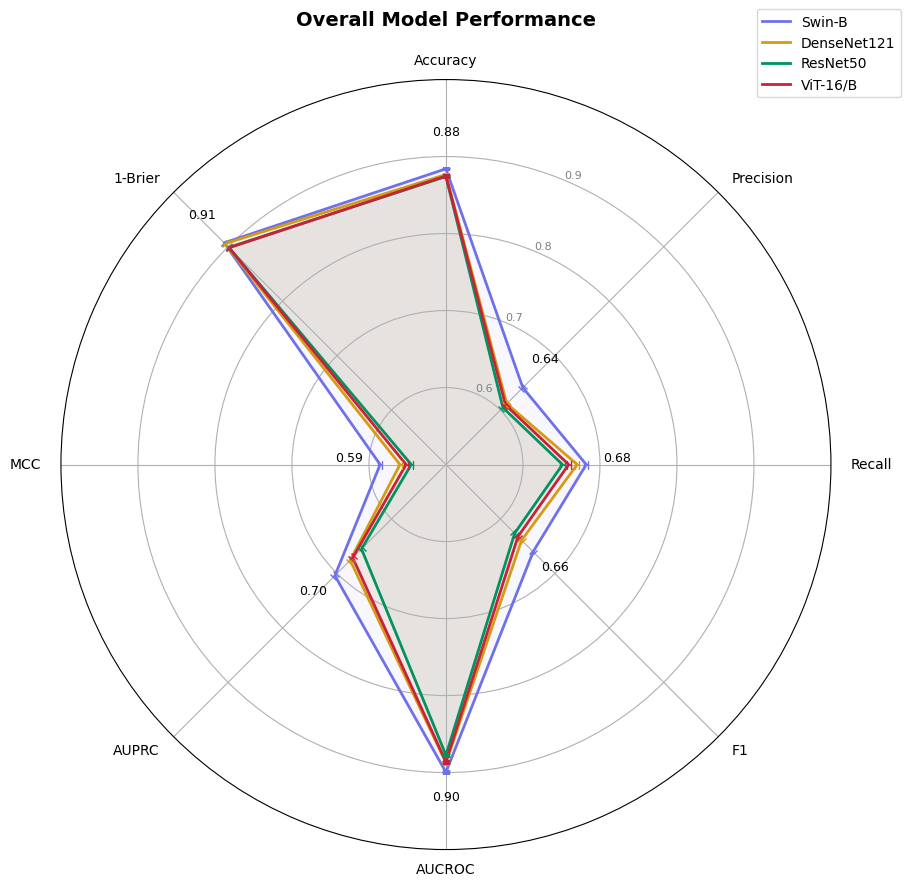

In [10]:
# 1. Identify Categories (Pathologies)
all_cols = df.columns.tolist()
categories = [c for c in all_cols if c != 'Model' and not c.endswith(' Std') and not c.endswith(' 95')]

N = len(categories)

# 2. Setup Angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories)

# Adjust label alignment
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (0, pi):
        label.set_horizontalalignment('center')
    elif 0 < angle < pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')

plt.ylim(0.5, 1)
plt.yticks([0.6, 0.7, 0.8, 0.9], ["0.6", "0.7", "0.8", "0.9"], color="grey", size=8)

colors = ['#6f71ea', '#d49c13', '#00935e', '#c8223a']

# 3. Main Plotting Loop
for i, row in df.iterrows():
    # Get values for this model
    values = row[categories].values.flatten().tolist()
    values += values[:1] # Repeat first value to close the shape
    
    # Current model color
    current_color = colors[i % len(colors)]

    # --- Plot the line ---
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'], color=current_color)
    
    # --- Fill the area ---
    ax.fill(angles, values, color=current_color, alpha=0.05)

    # --- ERROR BARS (Now for ALL models) ---
    # 1. Extract the error values (The "95" columns)
    error_cols = [cat + " 95" for cat in categories]
    errors = row[error_cols].values.flatten().tolist()
    
    # 2. Plot Error Bars
    # We use the same 'current_color' for the error bars so you can tell them apart
    ax.errorbar(angles[:-1], values[:-1], yerr=errors, 
                fmt='none', 
                ecolor=current_color,  # Match the model's color
                capsize=3, 
                elinewidth=1.2,        # Slightly thicker to see against the grid
                zorder=5)

    # --- Text Labels (Keep ONLY for Swin-B to prevent clutter) ---
    if row['Model'] == 'Swin-B':
        for angle, val in zip(angles[:-1], values[:-1]):
            ax.text(angle, val + 0.04, # Offset slightly more to clear the error bars
                    f"{val:.2f}",
                    horizontalalignment='center',
                    verticalalignment='bottom',
                    size=9,
                    color='black') 

# --- Final Touches ---
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.title("Overall Model Performance", size=14, pad=20, weight='bold')
plt.savefig('model_selection2.png', dpi=300, bbox_inches='tight')
plt.show()

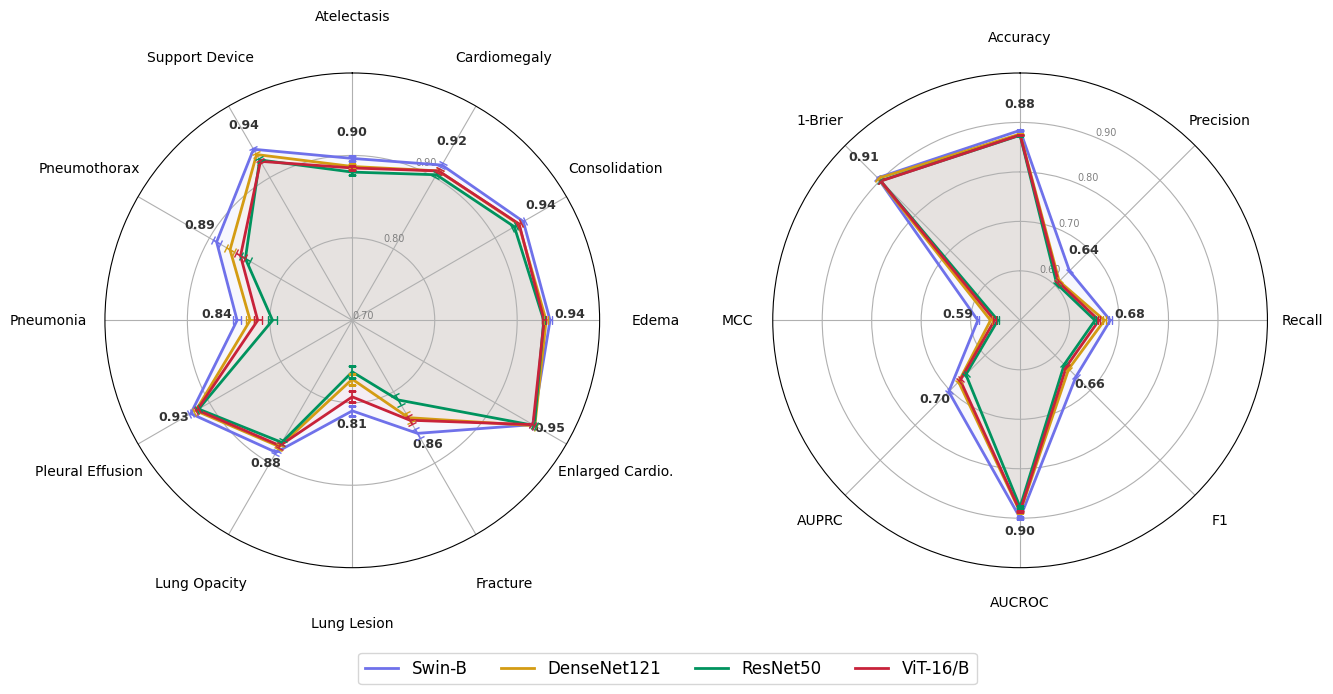

In [30]:
import matplotlib.pyplot as plt
from math import pi
import numpy as np

# 1. Setup Figure and Axes
# wspace=0.1 keeps them close together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace=0.35, bottom=0.15) 

colors = ['#6f71ea', '#d49c13', '#00935e', '#c8223a']

def draw_radar(ax, dataframe, y_lims, y_ticks, scale_data=True, show_labels=False, pad_val=40):
    all_cols = dataframe.columns.tolist()
    categories = [c for c in all_cols if c != 'Model' and not c.endswith(' Std') and not c.endswith(' 95')]
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    # Set X-Ticks and specific padding for this axis
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.tick_params(axis='x', pad=pad_val) # Independent padding applied here
    
    # Scale and Ticks
    ax.set_ylim(y_lims)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{t:.2f}" for t in y_ticks], color="grey", size=7)

    # Data Loop
    lines = [] 
    for i, row in dataframe.iterrows():
        factor = 100 if scale_data else 1.0
        values = (row[categories].values.flatten() / factor).tolist()
        values += values[:1]
        
        current_color = colors[i % len(colors)]
        
        # Plotting the model
        line, = ax.plot(angles, values, linewidth=2, label=row['Model'], color=current_color)
        ax.fill(angles, values, color=current_color, alpha=0.05)
        lines.append(line)

        # Error Bars
        error_cols = [cat + " 95" for cat in categories]
        errors = (row[error_cols].values.flatten() / factor).tolist()
        ax.errorbar(angles[:-1], values[:-1], yerr=errors, fmt='none', 
                    ecolor=current_color, capsize=3, elinewidth=1.2, zorder=5)

        # Print values for Swin-B on both charts
        if show_labels and row['Model'] == 'Swin-B':
            for angle, val in zip(angles[:-1], values[:-1]):
                offset = (y_lims[1] - y_lims[0]) * 0.08
                ax.text(angle, val + offset, f"{val:.2f}", ha='center', 
                        va='bottom', size=9, weight='bold', color='#333333')
    
    return lines

# 2. Plotting with custom padding for each
# Increase pad_val for the first chart to handle the long pathology names
handles = draw_radar(ax1, df, y_lims=(0.7, 1.0), y_ticks=[0.7, 0.8, 0.9], 
                     scale_data=True, show_labels=True, pad_val=30) 

# Smaller pad_val for the second chart since labels are shorter
draw_radar(ax2, df2, y_lims=(0.5, 1.0), y_ticks=[0.6, 0.7, 0.8, 0.9], 
           scale_data=False, show_labels=True, pad_val=15)

# 3. Shared Legend
fig.legend(handles=handles, labels=df['Model'].tolist(),
           loc='lower center', bbox_to_anchor=(0.5, 0.05),
           ncol=4, frameon=True, fontsize=12)

plt.savefig('combined_radar_charts.png', dpi=300, bbox_inches='tight')
plt.show()

# Image Size Visualization

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.lines as mlines

In [9]:
df = pd.read_csv('imagesize.csv', delimiter=';', decimal=',')
df

,Pathology,Metric,Model,Mean,Std,CI95,Lower,Upper
0,Pneumothorax,AUC-ROC,224,89.00,0.26,0.5096,88.4904,89.5096
1,Pneumothorax,AUC-ROC,512,89.35,0.26,0.5096,88.8404,89.8596
2,Pneumothorax,F1,224,49.01,0.63,1.2348,47.7752,50.2448
3,Pneumothorax,F1,512,49.96,0.64,1.2544,48.7056,51.2144
4,Pneumothorax,MCC,224,45.64,0.65,1.2740,44.3660,46.9140
5,Pneumothorax,MCC,512,46.66,0.67,1.3132,45.3468,47.9732
6,Fracture,AUC-ROC,224,85.83,0.30,0.5880,85.2420,86.4180
7,Fracture,AUC-ROC,512,86.15,0.30,0.5880,85.5620,86.7380
8,Fracture,F1,224,51.28,0.57,1.1172,50.1628,52.3972
9,Fracture,F1,512,53.34,0.56,1.0976,52.2424,54.4376


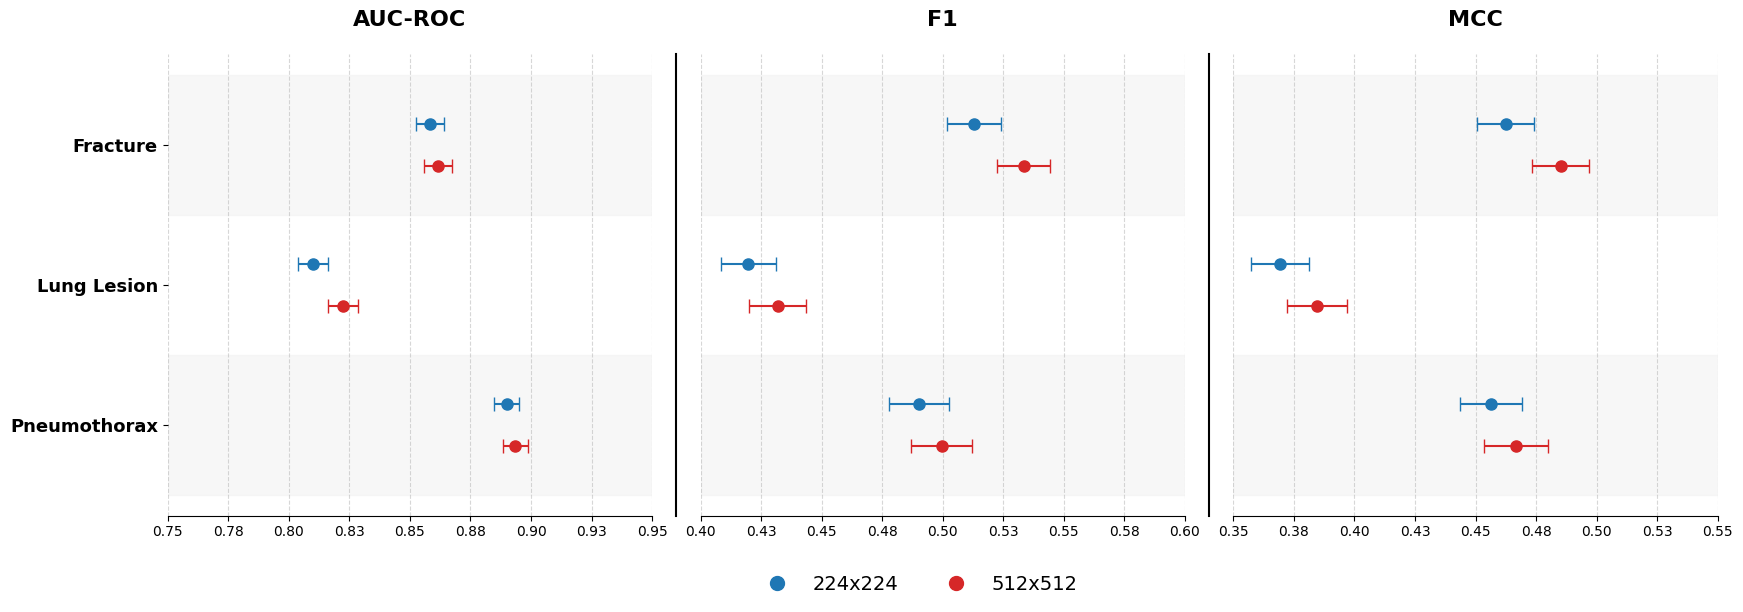

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter

def plot_merged_intervals(data):
    # 1. Data Conversion
    cols_to_scale = ['Mean', 'Lower', 'Upper']
    data[cols_to_scale] = data[cols_to_scale] / 100.0

    metrics = ['AUC-ROC', 'F1', 'MCC']
    pathologies = ['Pneumothorax', 'Lung Lesion', 'Fracture']
    
    # 2. Beautification Ranges
    metric_limits = {
        'AUC-ROC': (0.75, 0.95), 
        'F1': (0.4, 0.6),      
        'MCC': (0.35, 0.55)      
    }
    
    c_224, c_512 = '#1f77b4', '#d62728'
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, gridspec_kw={'wspace': 0.1})
    offset = 0.15 
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        metric_data = data[data['Metric'] == metric]
        
        # --- TICK FORMATTING ---
        # '%.1f' means float with 1 decimal place
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f')) 
        
        # Row Shading
        y_centers = np.arange(len(pathologies))
        for y in y_centers:
            if y % 2 == 0:
                ax.axhspan(y - 0.5, y + 0.5, color='#f0f0f0', alpha=0.5, zorder=0)
        
        # Plotting Points
        for i, path in enumerate(pathologies):
            row_224 = metric_data[(metric_data['Pathology'] == path) & (metric_data['Model'].astype(str) == '224')]
            row_512 = metric_data[(metric_data['Pathology'] == path) & (metric_data['Model'].astype(str) == '512')]
            
            if not row_224.empty:
                val = row_224.iloc[0]['Mean']
                err = [[val - row_224.iloc[0]['Lower']], [row_224.iloc[0]['Upper'] - val]]
                ax.errorbar(x=val, y=i + offset, xerr=err, fmt='o', color=c_224, capsize=5, markersize=8, zorder=3)
            
            if not row_512.empty:
                val = row_512.iloc[0]['Mean']
                err = [[val - row_512.iloc[0]['Lower']], [row_512.iloc[0]['Upper'] - val]]
                ax.errorbar(x=val, y=i - offset, xerr=err, fmt='o', color=c_512, capsize=5, markersize=8, zorder=3)

        if metric in metric_limits:
            ax.set_xlim(metric_limits[metric])
            
        ax.set_title(metric, fontsize=16, fontweight='bold', pad=20)
        ax.set_yticks(y_centers)
        if idx == 0: ax.set_yticklabels(pathologies, fontsize=13, fontweight='bold')
        else: ax.tick_params(axis='y', left=False) 
            
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if idx < 2:
            line = mlines.Line2D([1.05, 1.05], [0, 1], transform=ax.transAxes, color='black', linewidth=1.5)
            line.set_clip_on(False)
            ax.add_artist(line)

    # Legend & Save
    h_224 = mlines.Line2D([], [], color=c_224, marker='o', linestyle='None', markersize=10, label='224x224')
    h_512 = mlines.Line2D([], [], color=c_512, marker='o', linestyle='None', markersize=10, label='512x512')
    fig.legend(handles=[h_224, h_512], loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=14, frameon=False)
    plt.savefig('imagesize.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- LOAD DATA ---
df = pd.read_csv('imagesize.csv', delimiter=';', decimal=',')
# Cleanup columns if needed
for col in ["Std", "CI95"]:
    if col in df.columns:
        df = df.drop(col, axis=1)

plot_merged_intervals(df)

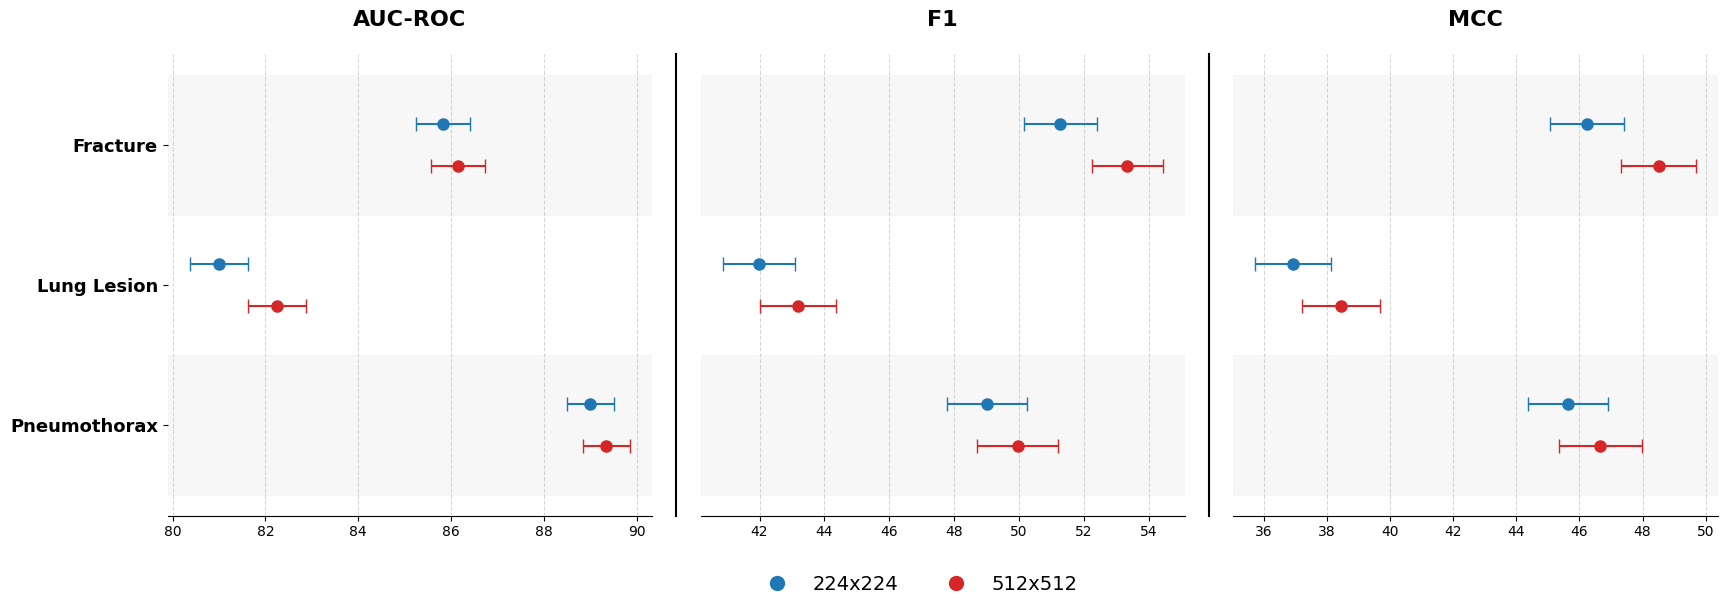

In [20]:
def plot_merged_intervals(data):
    metrics = ['AUC-ROC', 'F1', 'MCC']
    pathologies = ['Pneumothorax', 'Lung Lesion', 'Fracture']
    
    # Colors
    c_224 = '#1f77b4' # Blue
    c_512 = '#d62728' # Red
    
    # Setup Figure: 1 Row, 3 Columns
    # We increase wspace (width space) to make room for the divider lines
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, 
                             gridspec_kw={'wspace': 0.1})
    
    offset = 0.15 
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        metric_data = data[data['Metric'] == metric]
        y_centers = np.arange(len(pathologies))
        
        # --- 1. ADD ROW SHADING (Alternating Colors) ---
        # This makes it easy to read across the row
        for y in y_centers:
            if y % 2 == 0:
                # Add a faint grey rectangle for even rows
                ax.axhspan(y - 0.5, y + 0.5, color='#f0f0f0', alpha=0.5, zorder=0)
        
        for i, path in enumerate(pathologies):
            # Filter Data
            row_224 = metric_data[(metric_data['Pathology'] == path) & (metric_data['Model'].astype(str) == '224')]
            row_512 = metric_data[(metric_data['Pathology'] == path) & (metric_data['Model'].astype(str) == '512')]
            
            if row_224.empty or row_512.empty:
                continue
                
            # Plot 224
            val_224 = row_224.iloc[0]['Mean']
            err_224 = [[val_224 - row_224.iloc[0]['Lower']], [row_224.iloc[0]['Upper'] - val_224]]
            ax.errorbar(x=val_224, y=i + offset, xerr=err_224, 
                        fmt='o', color=c_224, capsize=5, markersize=8, zorder=3)
            
            # Plot 512
            val_512 = row_512.iloc[0]['Mean']
            err_512 = [[val_512 - row_512.iloc[0]['Lower']], [row_512.iloc[0]['Upper'] - val_512]]
            ax.errorbar(x=val_512, y=i - offset, xerr=err_512, 
                        fmt='o', color=c_512, capsize=5, markersize=8, zorder=3)

        # Formatting
        ax.set_title(metric, fontsize=16, fontweight='bold', pad=20)
        ax.set_yticks(y_centers)
        
        # Y-Labels only on the far left
        if idx == 0:
            ax.set_yticklabels(pathologies, fontsize=13, fontweight='bold')
        else:
            ax.tick_params(axis='y', left=False) 
            
        # Axis cleanup
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False) # Turn off default border
        
        # --- 2. ADD VERTICAL SEPARATOR LINE ---
        # We draw a line on the RIGHT side of the first two plots
        if idx < 2:
            # We use distinct line coordinates (1.05 is slightly outside the plot)
            line = mlines.Line2D([1.05, 1.05], [0, 1], transform=ax.transAxes, 
                                 color='black', linewidth=1.5, linestyle='-')
            line.set_clip_on(False) # Allow drawing outside the box
            ax.add_artist(line)

    # Legend
    # Create custom handles for cleaner legend
    h_224 = mlines.Line2D([], [], color=c_224, marker='o', linestyle='None', 
                          markersize=10, label='224x224')
    h_512 = mlines.Line2D([], [], color=c_512, marker='o', linestyle='None', 
                          markersize=10, label='512x512')
    
    fig.legend(handles=[h_224, h_512], loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=14, frameon=False)

    plt.savefig('imagesize.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- HOW TO LOAD DATA ---
df = pd.read_csv('imagesize.csv', delimiter=';', decimal=',')
df = df.drop(["Std", "CI95"], axis=1)
plot_merged_intervals(df)

In [10]:
df

,Pathology,Metric,Model,Mean,Lower,Upper
0,Pneumothorax,AUC-ROC,224,89.00,88.4904,89.5096
1,Pneumothorax,AUC-ROC,512,89.35,88.8404,89.8596
2,Pneumothorax,F1,224,49.01,47.7752,50.2448
3,Pneumothorax,F1,512,49.96,48.7056,51.2144
4,Pneumothorax,MCC,224,45.64,44.3660,46.9140
5,Pneumothorax,MCC,512,46.66,45.3468,47.9732
6,Fracture,AUC-ROC,224,85.83,85.2420,86.4180
7,Fracture,AUC-ROC,512,86.15,85.5620,86.7380
8,Fracture,F1,224,51.28,50.1628,52.3972
9,Fracture,F1,512,53.34,52.2424,54.4376


# Prevalence Analysis

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

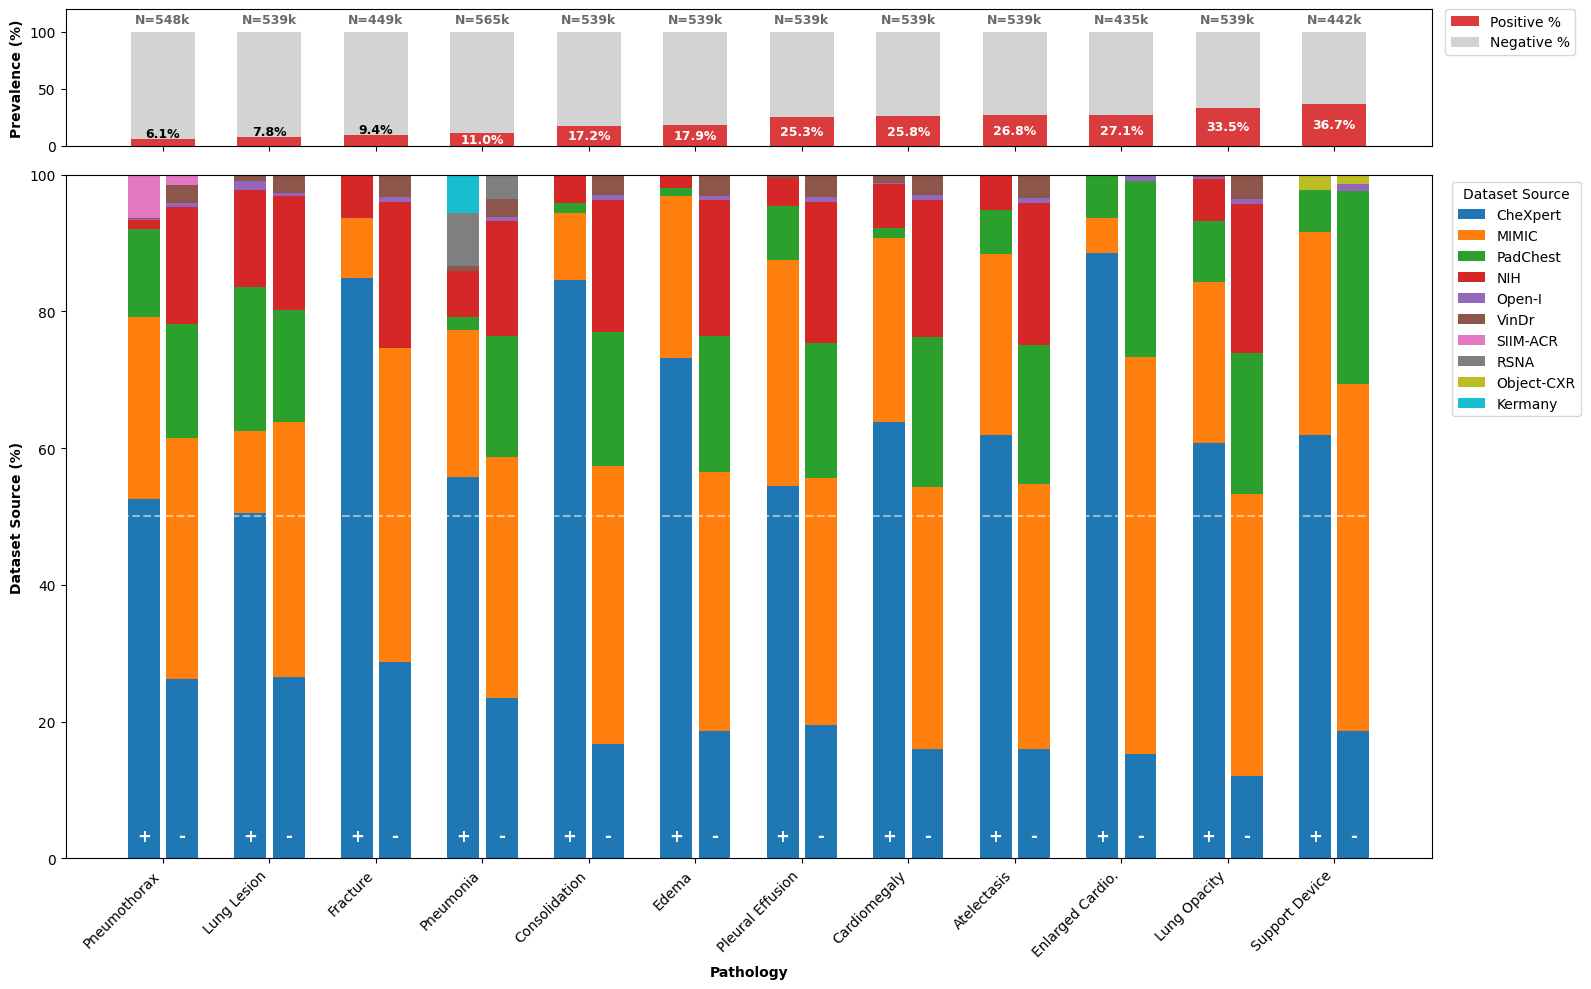

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATA LOADING & CLEANING ---
# We read the file and then manually clean the percentage strings
df_raw = pd.read_csv('prevalence_data.csv', delimiter=';')

# List of columns that contain the percentage strings (e.g., "53,47%")
cols_to_fix = ['ImagePercent', 'CheXpert', 'MIMIC', 'PadChest', 'NIH', 
               'Open-I', 'VinDr', 'SIIM-ACR', 'RSNA', 'Object-CXR', 'Kermany']

for col in cols_to_fix:
    if col in df_raw.columns:
        # 1. Convert to string 
        # 2. Replace comma with dot 
        # 3. Remove percentage sign
        df_raw[col] = df_raw[col].astype(str).str.replace(',', '.', regex=False).str.replace('%', '', regex=False)
        # 4. Convert to float (invalid entries become NaN)
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Now apply your original indexing logic
df = df_raw.set_index(['Pathology', 'Class'])

pathologies = df.index.get_level_values('Pathology').unique().tolist()
datasets = df.columns.tolist()[2:] # Columns after 'Images' and 'ImagePercent'

count_col = 'Images'
df[count_col] = pd.to_numeric(df[count_col], errors='coerce').fillna(0).astype(int)
total_counts = df[count_col].groupby(level=0).sum().reindex(pathologies).values

# Prepare Plotting Data
pos_percents = df.loc[(slice(None), 'Pos'), 'ImagePercent'].values
neg_percents = df.loc[(slice(None), 'Neg'), 'ImagePercent'].values

df_datasets = df[datasets].fillna(0)
# Normalize to 100% across datasets (handles small rounding differences)
df_datasets = df_datasets.div(df_datasets.sum(axis=1), axis=0) * 100

# --- 2. PLOTTING ---
fig, (ax_imb, ax_bias) = plt.subplots(2, 1, figsize=(16, 10), 
                                      sharex=True, 
                                      gridspec_kw={'height_ratios': [1, 5]})

plt.subplots_adjust(hspace=0.05)

x = np.arange(len(pathologies))
width = 0.6

# Top Plot: Positive vs Negative
ax_imb.bar(x, pos_percents, width, label='Positive %', color='#d62728', alpha=0.9)
ax_imb.bar(x, neg_percents, width, bottom=pos_percents, label='Negative %', color='lightgrey')

ax_imb.set_ylabel("Prevalence (%)", fontsize=10, weight='bold')
ax_imb.set_ylim(0, 120) 
ax_imb.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

# Labels for prevalence and sample size
for i, v in enumerate(pos_percents):
    label_y = v / 2 if v > 10 else v + 5
    color = 'white' if v > 10 else 'black'
    ax_imb.text(i, label_y, f"{v:.1f}%", ha='center', va='center', 
                fontsize=9, color=color, weight='bold')

for i, count in enumerate(total_counts):
    label = f"N={count/1000:.0f}k" if count >= 1000 else f"N={count}"
    ax_imb.text(i, 105, label, ha='center', va='bottom', 
                fontsize=9, color='dimgrey', weight='bold')

# Bottom Plot: Dataset Source Bias
dataset_colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))
bar_width = 0.30 
offset = 0.18
x_pos = x - offset
x_neg = x + offset

bottom_pos = np.zeros(len(pathologies))
bottom_neg = np.zeros(len(pathologies))

for i, dataset in enumerate(datasets):
    vals_pos = df_datasets.loc[(slice(None), 'Pos'), dataset].values
    vals_neg = df_datasets.loc[(slice(None), 'Neg'), dataset].values
    
    ax_bias.bar(x_pos, vals_pos, bar_width, bottom=bottom_pos, label=dataset, color=dataset_colors[i])
    ax_bias.bar(x_neg, vals_neg, bar_width, bottom=bottom_neg, color=dataset_colors[i])
    
    bottom_pos += vals_pos
    bottom_neg += vals_neg

ax_bias.set_ylabel("Dataset Source (%)", fontsize=10, weight='bold')
ax_bias.set_xlabel("Pathology", fontsize=10, weight='bold')
ax_bias.set_xticks(x)
ax_bias.set_xticklabels(pathologies, fontsize=10, rotation=45, ha='right')
ax_bias.set_ylim(0, 100)
ax_bias.axhline(50, color='white', linestyle='--', alpha=0.5)

# Annotate +/- symbols
for i in range(len(pathologies)):
    ax_bias.text(x_pos[i], 2, "+", ha='center', va='bottom', fontsize=12, color='white', weight='bold')
    ax_bias.text(x_neg[i], 2, "-", ha='center', va='bottom', fontsize=12, color='white', weight='bold')

# Clean Legend
handles, labels = ax_bias.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax_bias.legend(by_label.values(), by_label.keys(), 
               bbox_to_anchor=(1.01, 1), loc='upper left', title="Dataset Source")

plt.tight_layout()
plt.savefig('prevalence_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Re-Labeling

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

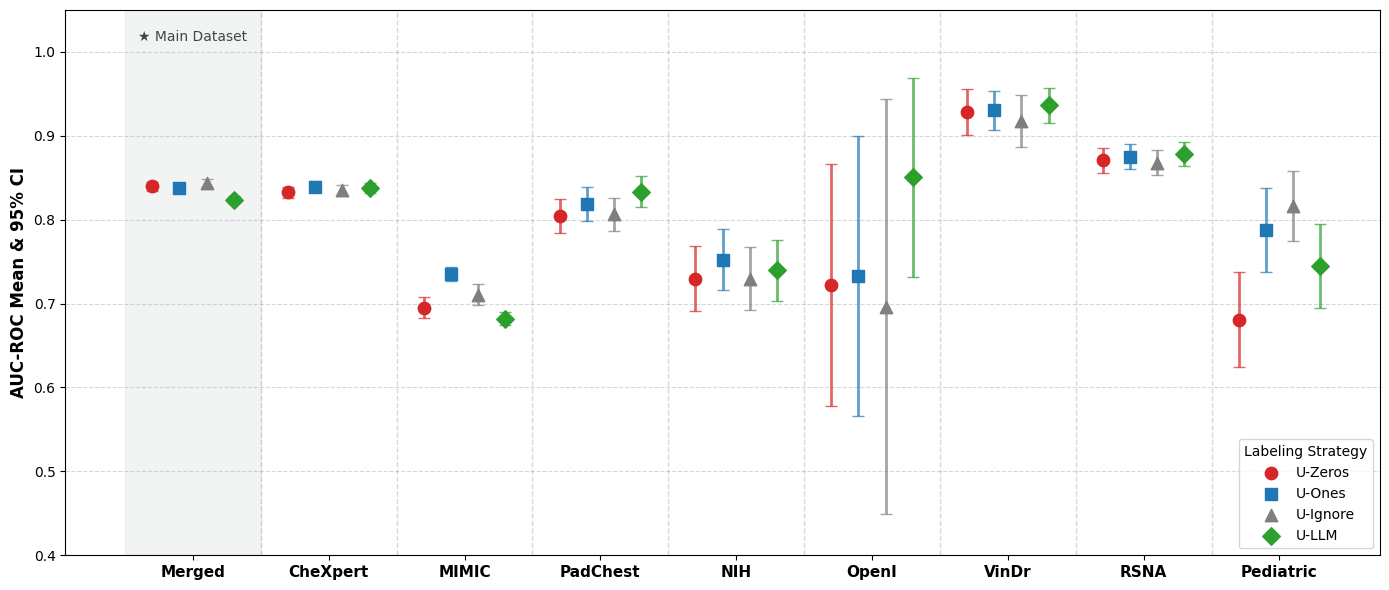

In [ ]:
# --- 1. PREPARE DATA ---
datasets = ['Merged', 'CheXpert', 'MIMIC', 'PadChest', 'NIH', 'OpenI', 'VinDr', 'RSNA', 'Pediatric']

# All values updated to decimals (0.0 - 1.0)
data_dict = {
    'U-Zeros':  {'mean': [0.7952, 0.8328, 0.6618, 0.8042, 0.7302, 0.7289, 0.9286, 0.8713, 0.6808], 
                 'ci_low': [0.7909, 0.8261, 0.6541, 0.7836, 0.6911, 0.5874, 0.9012, 0.8564, 0.6251], 
                 'ci_high': [0.7995, 0.8395, 0.6694, 0.8248, 0.7692, 0.8704, 0.9560, 0.8862, 0.7365]},
    
    'U-Ones':   {'mean': [0.8163, 0.8396, 0.6705, 0.8179, 0.7524, 0.7392, 0.9309, 0.8751, 0.7873], 
                 'ci_low': [0.8120, 0.8329, 0.6628, 0.7985, 0.7153, 0.5651, 0.9078, 0.8604, 0.7365], 
                 'ci_high': [0.8206, 0.8463, 0.6781, 0.8373, 0.7894, 0.9132, 0.9540, 0.8898, 0.8381]},
    
    'U-Ignore': {'mean': [0.7980, 0.8350, 0.6614, 0.8058, 0.7304, 0.6972, 0.9174, 0.8683, 0.8158], 
                 'ci_low': [0.7933, 0.8283, 0.6539, 0.7862, 0.6924, 0.4391, 0.8870, 0.8532, 0.7727], 
                 'ci_high': [0.8027, 0.8417, 0.6688, 0.8254, 0.7684, 0.9553, 0.9478, 0.8834, 0.8589]},
    
    'U-LLM':    {'mean': [0.8240, 0.8374, 0.6821, 0.8332, 0.7397, 0.8507, 0.9362, 0.8779, 0.7447], 
                 'ci_low': [0.8201, 0.8313, 0.6744, 0.8148, 0.7034, 0.7323, 0.9158, 0.8636, 0.6949], 
                 'ci_high': [0.8279, 0.8435, 0.6897, 0.8516, 0.7760, 0.9691, 0.9566, 0.8922, 0.7945]} 
}

methods = ['U-Zeros', 'U-Ones', 'U-Ignore', 'U-LLM']
colors = ['#d62728', '#1f77b4', '#7f7f7f', '#2ca02c'] 
markers = ['o', 's', '^', 'D'] 

# --- 2. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(datasets))
width = 0.6
offsets = np.linspace(-width/2, width/2, len(methods))

for i, method in enumerate(methods):
    means = data_dict[method]['mean']
    lowers = data_dict[method]['ci_low']
    uppers = data_dict[method]['ci_high']
    
    yerr_lower = np.array(means) - np.array(lowers)
    yerr_upper = np.array(uppers) - np.array(means)
    yerr = [yerr_lower, yerr_upper]
    
    # Error Bars
    ax.errorbar(x + offsets[i], means, yerr=yerr, 
                fmt='none', ecolor=colors[i], elinewidth=2, capsize=4, alpha=0.7)
    
    # Dots
    ax.scatter(x + offsets[i], means, label=method, color=colors[i], marker=markers[i], s=80, zorder=5)

# --- 3. IMPROVEMENTS ---
# Vertical Separator Lines
for j in range(len(datasets) - 1):
    ax.axvline(x=j + 0.5, color='grey', linestyle='--', alpha=0.3, linewidth=1)

# Highlight "Merged" Dataset
merged_idx = datasets.index('Merged')
ax.axvspan(merged_idx - 0.5, merged_idx + 0.5, color="#e6e8e9", alpha=0.5, zorder=0) 

# FIX: Changed y-coordinate from 101 to 1.01 to match decimal scale
ax.text(merged_idx, 1.01, "★ Main Dataset", ha='center', va='bottom', 
        fontsize=10, color="#444545")

# --- 4. FORMATTING ---
ax.set_ylabel("AUC-ROC Mean & 95% CI", fontsize=12, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11, weight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# The limit (0.4 to 1.05) is now correct for decimals
ax.set_ylim(0.4, 1.05)

ax.legend(title="Labeling Strategy", loc='lower right', frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('relabelling_comparison.png', dpi=300)